# Rice Crop Discovery Notebook

## Challenge Overview

<p align="justify">The goal of this challenge is to predict the presence of rice crops at a given location using satellite data. By the time you complete this challenge, you will have developed a rice crop classification model, which can distinguish between rice and non-rice fields.
</p>

## Load In Dependencies

In [1]:
# Supress Warnings
import warnings

warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Data Science
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Sentinel-Hub Tools
# https://sentinelhub-py.readthedocs.io/en/latest/
from sentinelhub import (
    SHConfig,
    DataCollection,
    MimeType,
    SentinelHubRequest,
    BBox,
    CRS
)

# Others
import unittest
import requests
import datetime
import getpass
from tqdm import tqdm

tqdm.pandas()

## Before you start!

This challenge uses the Sentinel Hub Python package for Copernicus Data Space Ecosystem. To use the service, please follow the next steps **make sure you do this first!**

To obtain your credentials, please follow the next steps and make sure you don't get any errors when trying to connect.

### Credentials

Credentials for Sentinel Hub services (`client_id` & `client_secret`) can be obtained in your [Dashboard](https://shapps.dataspace.copernicus.eu/dashboard/#/). In the User Settings you can create a new OAuth Client to generate these credentials. For more detailed instructions, visit the relevant [documentation page](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html).

Now that you have your `client_id` & `client_secret`, it is recommended to configure a new profile in your Sentinel Hub Python package. Instructions on how to configure your Sentinel Hub Python package can be found [here](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). Using these instructions you can create a profile specific to using the package for accessing Copernicus Data Space Ecosystem data collections. This is useful as changes to the config class are usually only temporary in your notebook and by saving the configuration to your profile you won't need to generate new credentials or overwrite/change the default profile each time you rerun or write a new Jupyter Notebook. 

If you are a first time user of the Sentinel Hub Python package for Copernicus Data Space Ecosystem, you should create a profile specific to the Copernicus Data Space Ecosystem. You can do this in the following cell:

In [3]:
# Never store OAuth credentials in a notebook or commit them to version control.
# The next cells load credentials from the local `cdse` Sentinel Hub profile.


## Authenticate to Sentinel Hub

In [2]:
# Only run this cell if you have not created a configuration.
config = SHConfig()
# Fill in your client ID and secret here - you can get these from the dashboard and a pop-up will appear to enter these
config.sh_client_id = getpass.getpass("Enter your SentinelHub client id")
config.sh_client_secret = getpass.getpass("Enter your SentinelHub client secret")
config.sh_base_url = 'https://sh.dataspace.copernicus.eu'
config.sh_token_url = 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token'
config.save("cdse")

Enter your SentinelHub client id ········
Enter your SentinelHub client secret ········


In [3]:
config = SHConfig("cdse")

### Pay attention to any errors when trying to connect

In [4]:
if not config.sh_client_id or not config.sh_client_secret:
    print("Warning! To use Process API, please provide the credentials (OAuth client ID and client secret).")

## Context
CarbonFarm helped design the [2023 EY Open Data Challenge focusing on rice](https://challenge.ey.com/challenges/level-1-crop-identification-global). There are two problems presented: classifying rice fields and predicting rice yields. We will focus on the first of the two.

The problem is as follows:

Use C-band SAR data from Sentinel-1 to classify GPS points as belonging to rice fields or not.

## The Data
### Synthetic Aperture Radar
In this problem, we use Synthetic Aperture Radar (SAR) as our source of data with which we wish to make a prediction. For a quick introduction to SAR data, see the guide [A Layman's Interpretation Guide to L-band and C-band Synthetic Aperture Radar data](https://www.researchgate.net/publication/339825765_A_Layman's_Interpretation_Guide_to_L-band_and_C-band_Synthetic_Aperture_Radar_data_v20). We recommend sections:

2: Briefly about Synthetic Aperture Radar
3.2.1: Copernicus Sentinel-1
4.2.7: Agriculture - Irrigated rice (Vietnam)

## Rice crops
To assist in your understanding, we recommend considering the growth of rice crops over the course of a season. Typically lasting anywhere between 90 and 120 days in Vietnam, rice plants go through multiple stages of growth that will impact the SAR images over time. The key stages are presented below:

![image](rice_growth_stages.png)

## Labelled Data
The labelled data is provided in the CSV below. It contains the GPS locations (latitude and longitude pairs) and the land use classification. The goal is, based on the GPS location, find and process relevant Sentinel-1 SAR data and predict the land use class.

Crop_Location_Data.csv (see attachment)

## This Notebook

In this notebook, we will demonstrate a basic model workflow that can serve as a starting point for the challenge. The basic model has been built to predict rice crops against non-rice crops (which might include forest, other vegetation and water bodies) using features from the Sentinel-1 Radiometrically Terrain Corrected (RTC) dataset as predictor variables. In this demonstration, we have used two features from the Sentinel-1 dataset, namely:
- VV (Vertical transmit polarization – Vertical receive polarization), and 
- VH (Vertical transmit polarization – Horizontal receive polarization)

We have extracted the VV band and VH band data from the Sentinel-1 dataset for one day (21st March 2020), with an assumption that VV and VH values for this day are representative of VV and VH values for the entire year (2020) for a given location.
    
Please note that this notebook is just a starting point. We have made many assumptions in this notebook that you may think are not best for solving the challenge effectively. You are encouraged to modify these functions, rewrite them, or try an entirely new approach or include other sources of data (be mindful of the quota if using Sentinel Hub!).

## Response Variable

Before building the model, we need to load in the rice crop data. We have data from a certain region in Vietnam for the year 2020. The data consists of geographical locations (Latitude and Longitude pairs) with a column specifying if the crop present in each location is rice or not.  

In [5]:
crop_presence_data = pd.read_csv("Crop_Location_Data.csv")
crop_presence_data.head()

,Latitude and Longitude,Class of Land
0,"(10.323727047081501, 105.2516346045924)",Rice
1,"(10.322364360592521, 105.27843410554115)",Rice
2,"(10.321455902933202, 105.25254306225168)",Rice
3,"(10.324181275911162, 105.25118037576274)",Rice
4,"(10.324635504740822, 105.27389181724476)",Rice


## Predictor Variables

<p align ="justify">Now that we have our crop location data, it is time to gather the predictor variables from the Sentinel-1 dataset. Sentinel-1 radar data penetrates through the clouds, thus helping us to get the band values regardless of weather events. Sentinel-1 offers two band values, VV and VH, which can help us in distinguishing between the rice and non rice crops. 
        
<ul>
<li>VV - gamma naught values of signal transmitted with vertical polarization and received with vertical polarization with radiometric terrain correction applied.

<li>VH - gamma naught values of signal transmitted with vertical polarization and received with horizontal polarization with radiometric terrain correction applied.
</ul>

<h4 style="color:rgb(195, 52, 235)"><strong>Tip 1</strong></h4>
<p align="justify">Participants might explore other combinations of bands from the Sentinel-1 data. For example, you can use mathematical combinations of bands to generate various <a href="https://challenge.ey.com/api/v1/storage/admin-files/3868217534768359-63ca8dc8aea56e00146e3489-Comprehensive%20Guide%20-%20Satellite%20Data.docx">vegetation indices (see original challenge document)</a> which can then be used as features in your model.


### Accessing the Sentinel-1 Data

<p align = "Justify">To get the Sentinel-1 data, we write a function called <i><b>get_sentinel_data.</b></i> This function will fetch VV and VH band values for a particular location over the specified time window. In this example, we have extracted VV and VH values for a day (21st March 2020). </p>

<h4 style="color:rgb(195, 52, 235)"><strong>Tip 2</strong></h4>
<p align="justify"> Extract VV and VH band values for an entire year. Different land classes (e.g., agriculture, water, urban) will have different annual variability. This variability will be better than a single date for accurately identifying land classes. Please find below a demonstration of extracting data for a day (21st March 2020).

In [6]:
# This is the script that will be used to extract the VV and VH bands from Sentinel-Hub
# You do not need to modify anything here (you can, if you really want to)

evalscript_sar = """
  function setup() {
    return {
      input: ["VH", "VV"],
      output: { bands: 2, sampleType: "FLOAT32"}
    }
  }

function evaluatePixel(sample) {
  var VH = sample.VH;
  var VV = sample.VV;

  return [VH, VV, sample.dataMask];
}
"""

In [9]:
def get_sentinel_data(latlong, timeslice):
    latlong = latlong.replace('(', '').replace(')', '').replace(' ', '').split(',')

    # Create a small bounding box around the point of interest; Sentinel Hub requires a bounding box
    delta = 0.00001  # approx 1 meter
    bbox_of_interest = BBox(
        bbox=(
            float(latlong[1]) - delta,
            float(latlong[0]) - delta,
            float(latlong[1]) + delta,
            float(latlong[0]) + delta
        ), crs=CRS.WGS84
    )

    # The scale should be according to our selected CRS which is for degrees
    resolution = 10  # meters per pixel 
    scale = resolution / 111320.0  # degrees per pixel for CRS=WGS84 (EPSG:4326) -> take a look at projected vs geographic coordinates if you are interested

    # You do not need to modify anything here (you can, if you really want to)
    request = SentinelHubRequest(
        evalscript=evalscript_sar,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW.define_from(
                    "s1iw", service_url=config.sh_base_url
                ),
                time_interval=timeslice,
                other_args={
                    "dataFilter": {
                        "orbitDirection": "ASCENDING",
                    },
                    "processing": {
                        "resolution": "HIGH",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox_of_interest,
        resolution=[scale, scale],
        config=config,
        data_folder="./results",
    )

    data = np.squeeze(request.get_data())

    return data

Explore the approach of building a bounding box (e.g., 5x5 pixels) around the given latitude and longitude positions and then extract the aggregated band values (e.g., average, median) to get normalized band values to build the model. Radar data has inherent variability at the pixel level due to variable scattering response from the target. This effect is called “speckle” and it is common to filter the data to smooth these variations. Try using a 3x3, 5x5 or 7x7 window around the specific latitude and longitude point to get improved results.

<h4 style="color:rgb(195, 52, 235)"><strong>Pay attention to the geographical characteristics of the data and the desired resolution.  </strong></h4>

In [ ]:
## Function call to extract VH and VV Values
timeslice = ("2020-03-20", "2020-03-21") ### only one day
vh_vv = []

# This might take up to 5 minutes...
for coordinates in tqdm(crop_presence_data['Latitude and Longitude']):
    vh_vv.append(get_sentinel_data(coordinates, timeslice))

In [9]:
vh_vv_data = pd.DataFrame(vh_vv, columns=['vh', 'vv'])

In [10]:
vh_vv_data.head()

,vh,vv
0,0.052684,0.208794
1,0.010663,0.136826
2,0.018912,0.122309
3,0.024170,0.120951
4,0.059458,0.282601


## Joining the predictor variables and response variables
Now that we have extracted our predictor variables, we need to join them onto the response variable.

In [ ]:
crop_data = pd.concat([crop_presence_data, vh_vv_data], axis=1)
crop_data.head()

## Model Building

<p align="justify"> Now let us select the columns required for our model building exercise. We will consider only VV and VH for our model. </p>

In [12]:
crop_data = crop_data[['vh', 'vv', 'Class of Land']]

### Train and Test Split 

<p align="justify">We will now split the data into 70% training data and 30% test data.

In [13]:
X = crop_data.drop(columns=['Class of Land']).values
y = crop_data['Class of Land'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

### Feature Scaling 

<p align="justify"> Before initiating the model training we may have to execute different data pre-processing steps. Here we are demonstrating the scaling of VV and VH variable by using Standard Scaler.</p>

In [14]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Model Training

<p justify ="align">Now that we have the data in a format appropriate for machine learning, we can begin training a model. In this demonstration notebook, we have used a binary logistic regression model from the scikit-learn library. </p> 

In [15]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

## Model Evaluation

For evaluation we will generate the classification report and will plot the confusion matrix.

In [16]:
insample_predictions = model.predict(X_train)

In [17]:
print("Insample Accuracy {0:.2f}%".format(100 * accuracy_score(insample_predictions, y_train)))
print(classification_report(insample_predictions, y_train))

Insample Accuracy 60.95%
              precision    recall  f1-score   support

    Non Rice       0.51      0.64      0.57       170
        Rice       0.70      0.59      0.64       250

    accuracy                           0.61       420
   macro avg       0.61      0.61      0.61       420
weighted avg       0.63      0.61      0.61       420



<p> For plotting a confusion matrix we define the function <b><i>plot_confusion_matrix</i></b>.

In [10]:
def plot_confusion_matrix(true_value, predicted_value, title, labels):
    '''
    Plot a confusion matrix.
    
    Parameters:
    ----------
    true_value : List[str]
      The ground truth value for comparision.
    predicted_value : List[str]
      The values predicted by the model.
    title : str
      Title of the plot.
    labels : List[str]
      The x and y labels of the plot.
    '''
    cm = confusion_matrix(true_value, predicted_value)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap='Blues');
    ax.set_xlabel('Predicted labels');
    ax.set_ylabel('True labels');
    ax.set_title(title);
    ax.xaxis.set_ticklabels(labels);
    ax.yaxis.set_ticklabels(labels);

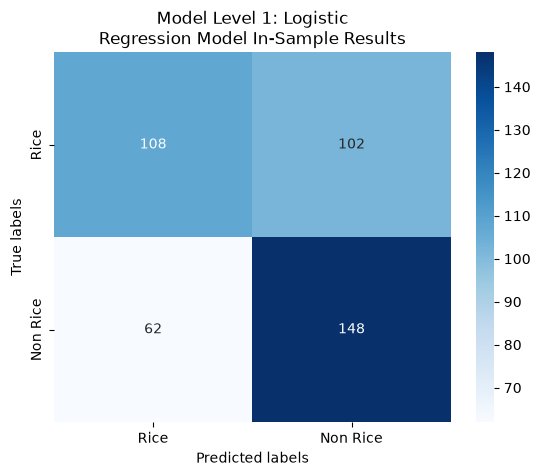

In [19]:
plot_confusion_matrix(
    y_train,
    insample_predictions,
    "Model Level 1: Logistic\nRegression Model In-Sample Results",
    ['Rice', 'Non Rice']
)

### Out-Sample Evaluation

In [20]:
outsample_predictions = model.predict(X_test)

In [21]:
print("Accuracy {0:.2f}%".format(100 * accuracy_score(outsample_predictions, y_test)))
print(classification_report(y_test, outsample_predictions))

Accuracy 67.22%
              precision    recall  f1-score   support

    Non Rice       0.72      0.57      0.63        90
        Rice       0.64      0.78      0.70        90

    accuracy                           0.67       180
   macro avg       0.68      0.67      0.67       180
weighted avg       0.68      0.67      0.67       180



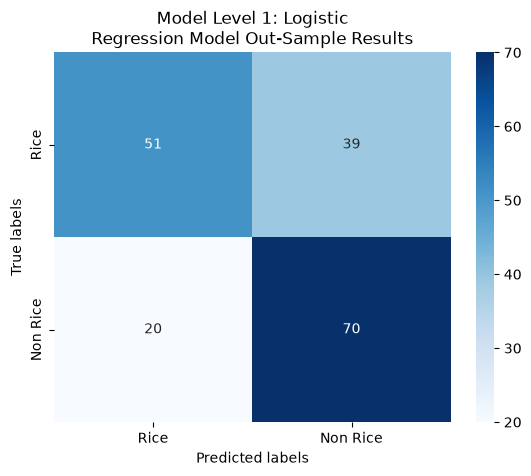

In [22]:
plot_confusion_matrix(
    y_test,
    outsample_predictions,
    "Model Level 1: Logistic\nRegression Model Out-Sample Results",
    ['Rice', 'Non Rice']
)

From the above, we see that the model is able to achieve an F1 score of <b>0.67</b>. This is not a very good score, so your goal is to improve this score.  

# To do
## Python coding
### Task 1.a
The function `get_sentinel_data` is poorly written and does not follow best coding practices. Identify a couple of dot points outlining what is wrong with the function and rewrite the function to correct these mistakes.

The original function has several correctness, security, and maintainability issues:

- Coordinates are parsed with brittle string replacement and there is no validation of latitude, longitude, dates, resolution, or window size.
- A fixed degree offset is not a fixed ground distance and changes with latitude. The request also mixes a WGS84 bounding box (degrees) with a metre-based intent.
- The evalscript declares two output bands but returns three values, and `np.squeeze` makes the return shape depend on the requested window.
- `dataMask` is returned but not declared as an input or used, so no-data pixels can be mistaken for valid zero backscatter.
- The function depends on mutable globals, has no type contract or docstring, and writes every response to `./results` even when persistence is not requested.

The implementation below validates its inputs, creates the box in a local UTM CRS so that its dimensions are in metres, requests exactly `h × w` pixels, applies `dataMask`, and always returns an array with shape `(h, w, 2)` in **VH, VV** order. This also completes Task 1.b.

Implementation details were checked against the official [SentinelHubRequest API](https://sentinelhub-py.readthedocs.io/en/latest/reference/sentinelhub.api.process.html), [Sentinel-1 GRD processing options](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/S1GRD.html), and [Evalscript/dataMask documentation](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Evalscript.html).


In [ ]:
# evalscript_sar = """
#   function setup() {
#     return {
#       input: ["VH", "VV"],
#       output: { bands: 2, sampleType: "FLOAT32"}
#     }
#   }

# function evaluatePixel(sample) {
#   var VH = sample.VH;
#   var VV = sample.VV;

#   return [VH, VV, sample.dataMask];
# }
# """

In [12]:
import re
from collections.abc import Sequence
from numbers import Real
from typing import Any

from pyproj import Transformer


EVALSCRIPT_SAR_MASKED = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: ["VH", "VV", "dataMask"],
      units: ["LINEAR_POWER", "LINEAR_POWER", "DN"]
    }],
    output: { bands: 3, sampleType: "FLOAT32" }
  };
}

function evaluatePixel(sample) {
  return [sample.VH, sample.VV, sample.dataMask];
}
"""


def parse_latlong(latlong: str | Sequence[Real]) -> tuple[float, float]:
    """Return a validated ``(latitude, longitude)`` pair."""
    if isinstance(latlong, str):
        match = re.fullmatch(
            r"\s*\(?\s*([-+]?\d+(?:\.\d+)?)\s*,\s*([-+]?\d+(?:\.\d+)?)\s*\)?\s*",
            latlong,
        )
        if match is None:
            raise ValueError("Coordinates must look like '(latitude, longitude)'.")
        latlong = tuple(map(float, match.groups()))

    if (
        not isinstance(latlong, Sequence)
        or isinstance(latlong, (str, bytes))
        or len(latlong) != 2
        or not all(isinstance(value, Real) for value in latlong)
    ):
        raise TypeError("Coordinates must be a string or a two-number sequence.")

    latitude, longitude = map(float, latlong)
    if not np.isfinite([latitude, longitude]).all():
        raise ValueError("Coordinates must be finite.")
    if not -90 <= latitude <= 90 or not -180 <= longitude <= 180:
        raise ValueError("Latitude must be in [-90, 90] and longitude in [-180, 180].")
    return latitude, longitude


def _validate_window(h: int, w: int, resolution: float) -> None:
    if isinstance(h, bool) or isinstance(w, bool) or not isinstance(h, int) or not isinstance(w, int):
        raise TypeError("h and w must be integers.")
    if h <= 0 or w <= 0:
        raise ValueError("h and w must be positive.")
    if not isinstance(resolution, Real) or isinstance(resolution, bool) or resolution <= 0:
        raise ValueError("resolution must be a positive number of metres per pixel.")

### resollution = any metres in a pixel
def _pixel_window_bbox(
    latitude: float,
    longitude: float,
    h: int,
    w: int,
    resolution: float,
) -> BBox:
    """Build a point-centred metric bounding box in the point's UTM zone."""
    utm_crs = CRS.get_utm_from_wgs84(lng=longitude, lat=latitude)
    transformer = Transformer.from_crs(CRS.WGS84.pyproj_crs(), utm_crs.pyproj_crs(), always_xy=True)
    easting, northing = transformer.transform(longitude, latitude)
    half_width = w * resolution / 2
    half_height = h * resolution / 2
    return BBox(
        (
            easting - half_width,
            northing - half_height,
            easting + half_width,
            northing + half_height,
        ),
        crs=utm_crs,
    )



### Task 1.b
Radar data has inherent variability at the pixel level due to variable scattering response from the target. This effect is called “speckle” and it is common to filter the data to smooth these variations.

We may want to explore the approach of building a bounding box (e.g. 5x5 pixels) around the given latitude and longitude positions before we extract the aggregated band values (e.g., average, median). These normalized band values may help to build better models.

*To do:* adapt the above function `get_sentinel_data` to return data from a bounding box of size `h` by `w` pixels.

In [13]:

def get_sentinel_data(
    latlong: str | Sequence[Real],
    timeslice: tuple[str, str],
    *,
    h: int = 1,
    w: int = 1,
    resolution: float = 10.0,
    sh_config: SHConfig | None = None,
    request_factory: Any = SentinelHubRequest,
) -> np.ndarray:
    """Fetch an ``h × w`` Sentinel-1 window as masked VH and VV linear power.

    Returns
    -------
    numpy.ndarray
        Float array of shape ``(h, w, 2)``. The final axis is ``[VH, VV]``;
        pixels outside ``dataMask`` are represented by ``NaN``.
    """
    latitude, longitude = parse_latlong(latlong)
    ##################################
    _validate_window(h, w, resolution)
    #################################
    if not isinstance(timeslice, tuple) or len(timeslice) != 2:
        raise TypeError("timeslice must be a (start, end) tuple.")

    active_config = sh_config if sh_config is not None else config
    bbox = _pixel_window_bbox(latitude, longitude, h, w, resolution)
    collection = DataCollection.SENTINEL1_IW.define_from(
        "s1iw", service_url=active_config.sh_base_url
    )
    request = request_factory(
        evalscript=EVALSCRIPT_SAR_MASKED,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=collection,
                time_interval=timeslice,
                other_args={
                    "dataFilter": {"orbitDirection": "ASCENDING"},
                    "processing": {
                        "backCoeff": "GAMMA0_TERRAIN",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=(w, h),
        config=active_config,
    )

    response = np.asarray(request.get_data()[0], dtype=float)
    if response.shape == (3, h, w):  # Be tolerant of band-first TIFF readers.
        response = np.moveaxis(response, 0, -1)
    if response.shape != (h, w, 3):
        raise RuntimeError(f"Expected a {(h, w, 3)} response, received {response.shape}.")

    bands = response[..., :2].copy()
    bands[response[..., 2] <= 0] = np.nan
    return bands

### Task 2.a
The above notebook was written to handle data in `DataFrame`s. While this has it's advantages, it also has disadvantages. 
* Write a class `CropObservation` to represent a single geographical point with Rice/Non-Rice classification label
* Add an attribute(s) to hold the SAR band data `vv` and `vh` using a 9x9 pixel bounding box

In [14]:
from dataclasses import dataclass
from typing import Literal


@dataclass(slots=True)
class CropObservation:
    """One labelled point and its point-centred 9×9 Sentinel-1 window."""

    latitude: float
    longitude: float
    land_class: str
    vh: np.ndarray
    vv: np.ndarray

    def __post_init__(self) -> None:
        self.latitude, self.longitude = parse_latlong((self.latitude, self.longitude))
        self.vh = np.asarray(self.vh, dtype=float)
        self.vv = np.asarray(self.vv, dtype=float)
        if self.vh.shape != (9, 9) or self.vv.shape != (9, 9):
            raise ValueError("vh and vv must both be 9×9 arrays.")
        if not isinstance(self.land_class, str) or not self.land_class.strip():
            raise ValueError("land_class must be a non-empty string.")

    @classmethod
    def from_location(
        cls,
        latlong: str | Sequence[Real],
        land_class: str,
        timeslice: tuple[str, str],
        *,
        resolution: float = 10.0,
        **request_kwargs: Any,
    ) -> "CropObservation":
        """Fetch the standard 9×9 SAR window and construct an observation."""
        latitude, longitude = parse_latlong(latlong)
        pixels = get_sentinel_data(
            (latitude, longitude),
            timeslice,
            h=9,
            w=9,
            resolution=resolution,
            **request_kwargs,
        )
        return cls(latitude, longitude, land_class, vh=pixels[..., 0], vv=pixels[..., 1])

    @classmethod
    def from_row(
        cls,
        row: pd.Series,
        timeslice: tuple[str, str],
        **request_kwargs: Any,
    ) -> "CropObservation":
        """Construct an observation from one row of ``Crop_Location_Data.csv``."""
        return cls.from_location(
            row["Latitude and Longitude"],
            row["Class of Land"],
            timeslice,
            **request_kwargs,
        )

    def band(self, name: Literal["vh", "vv"], box_size: int = 9) -> np.ndarray:
        """Return a centred odd-sized view of a SAR band."""
        if name not in {"vh", "vv"}:
            raise ValueError("name must be 'vh' or 'vv'.")
        if isinstance(box_size, bool) or not isinstance(box_size, int):
            raise TypeError("box_size must be an integer.")
        if box_size < 1 or box_size > 9 or box_size % 2 == 0:
            raise ValueError("box_size must be one of 1, 3, 5, 7, or 9.")
        margin = (9 - box_size) // 2
        values = getattr(self, name)
        return values[margin : margin + box_size, margin : margin + box_size].copy()

    def to_map(self, zoom_start: int = 16) -> folium.Map:
        """Create an interactive map centred on this observation."""
        location = [self.latitude, self.longitude]
        crop_map = folium.Map(location=location, zoom_start=zoom_start)
        folium.Marker(
            location=location,
            tooltip=self.land_class,
            popup=f"{self.land_class}: ({self.latitude:.6f}, {self.longitude:.6f})",
        ).add_to(crop_map)
        return crop_map

    def model_features(self, box_sizes: Sequence[int] = (3, 5, 7, 9)) -> pd.Series:
        """Summarise centred windows into robust, model-ready features."""
        features: dict[str, float] = {}
        for box_size in box_sizes:
            vh = self.band("vh", box_size)
            vv = self.band("vv", box_size)
            for name, values in (("vh", vh), ("vv", vv)):
                features[f"{name}_mean_{box_size}"] = float(np.nanmean(values))
                features[f"{name}_median_{box_size}"] = float(np.nanmedian(values))
                features[f"{name}_std_{box_size}"] = float(np.nanstd(values))
                features[f"{name}_iqr_{box_size}"] = float(
                    np.nanpercentile(values, 75) - np.nanpercentile(values, 25)
                )

            denominator = vv + vh
            with np.errstate(divide="ignore", invalid="ignore"):
                rvi = np.divide(4 * vh, denominator, out=np.full_like(vh, np.nan), where=denominator != 0)
                ratio = np.divide(vh, vv, out=np.full_like(vh, np.nan), where=vv != 0)
            features[f"rvi_median_{box_size}"] = float(np.nanmedian(rvi))
            features[f"vh_vv_ratio_median_{box_size}"] = float(np.nanmedian(ratio))

        return pd.Series(features, name=f"{self.latitude},{self.longitude}")


### Task 2.b

`CropObservation.to_map()` returns an interactive `folium.Map` centred on the observation. The marker tooltip shows the land class and its popup includes the class and coordinates. Returning the map—rather than displaying it inside the method—keeps the method reusable in notebooks, web applications, and tests.


In [75]:
# Fetch one real 9×9 observation and render its interactive location map.
map_example_timeslice = ("2020-03-20", "2020-03-21")
map_example_observation = CropObservation.from_row(
    crop_presence_data.iloc[0],
    map_example_timeslice,
)
observation_map = map_example_observation.to_map(zoom_start=17)

# Lightweight validation of the object returned by Task 2.b.
assert isinstance(observation_map, folium.Map)
assert map_example_observation.land_class in observation_map.get_root().render()
observation_map


### Task 2.c
Our new class holds the SAR band data for a 9x9 pixel bounding box. We may, however, want to test smaller box sizes.
* Add a method(s) to your class that retrieves `vv` or `vh` data for a smaller bounding box size
* Add any unit tests you see necessary to your class
* Add any additional methods that you may find useful to transform data for your model

In [16]:
class TestSentinelData(unittest.TestCase):
    def test_parse_latlong(self):
        self.assertEqual(parse_latlong("(10.25, 105.75)"), (10.25, 105.75))
        self.assertEqual(parse_latlong("(10.25, 105.75"), (10.25, 105.75))
        with self.assertRaises(ValueError):
            parse_latlong("(91, 0)")

    def test_exact_window_shape_and_mask(self):
        class FakeRequest:
            kwargs: dict[str, Any] = {}

            def __init__(self, **kwargs: Any):
                type(self).kwargs = kwargs

            def get_data(self):
                width, height = self.kwargs["size"]
                result = np.empty((height, width, 3), dtype=np.float32)
                result[..., 0] = 0.1  # VH
                result[..., 1] = 0.2  # VV
                result[..., 2] = 1.0  # dataMask
                result[0, 0, 2] = 0.0
                return [result]

        result = get_sentinel_data(
            (10.25, 105.75),
            ("2020-03-20", "2020-03-21"),
            h=3,
            w=5,
            sh_config=config,
            request_factory=FakeRequest,
        )
        self.assertEqual(result.shape, (3, 5, 2))
        self.assertTrue(np.isnan(result[0, 0]).all())
        self.assertTrue(np.allclose(result[1:, :, 0], 0.1))
        self.assertEqual(FakeRequest.kwargs["size"], (5, 3))
        self.assertAlmostEqual(FakeRequest.kwargs["bbox"].geometry.bounds[2] - FakeRequest.kwargs["bbox"].geometry.bounds[0], 50.0)
        self.assertAlmostEqual(FakeRequest.kwargs["bbox"].geometry.bounds[3] - FakeRequest.kwargs["bbox"].geometry.bounds[1], 30.0)


class TestCropObservation(unittest.TestCase):
    def setUp(self):
        values = np.arange(81, dtype=float).reshape(9, 9)
        self.observation = CropObservation(10.25, 105.75, "Rice", vh=values, vv=values + 1)

    def test_centered_subwindow(self):
        expected = self.observation.vh[3:6, 3:6]
        np.testing.assert_array_equal(self.observation.band("vh", 3), expected)
        with self.assertRaises(ValueError):
            self.observation.band("vv", 4)

    def test_model_features_are_finite(self):
        features = self.observation.model_features(box_sizes=(3, 9))
        self.assertIn("rvi_median_9", features)
        self.assertTrue(np.isfinite(features).all())

    def test_map_contains_location(self):
        rendered = self.observation.to_map().get_root().render()
        self.assertIn("10.25", rendered)
        self.assertIn("105.75", rendered)
        self.assertIn("Rice", rendered)


test_suite = unittest.TestSuite()
test_suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(TestSentinelData))
test_suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(TestCropObservation))
unittest.TextTestRunner(verbosity=2).run(test_suite)

test_exact_window_shape_and_mask (__main__.TestSentinelData.test_exact_window_shape_and_mask) ... ok
test_parse_latlong (__main__.TestSentinelData.test_parse_latlong) ... ok
test_centered_subwindow (__main__.TestCropObservation.test_centered_subwindow) ... ok
test_map_contains_location (__main__.TestCropObservation.test_map_contains_location) ... ok
test_model_features_are_finite (__main__.TestCropObservation.test_model_features_are_finite) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.025s

OK


<unittest.runner.TextTestResult run=5 errors=0 failures=0>

## Model training: leakage-aware Sentinel-1 time series

### Objective and success criterion

The original 70/30 row split treats observations as independent. That assumption is unsafe for spatial data: nearby points share land cover, acquisition geometry, weather and management history. The modelling workflow below therefore:

1. audits spatial dependence before fitting;
2. uses the notebook's suggested 9×9 neighbourhood, dual-polarization RVI and a full-year time series;
3. excludes latitude, longitude and site ID from the predictors;
4. compares models using **leave-one-site-out** validation; and
5. reports pooled and per-site results, not only a single random-split score.

The primary success criterion is macro F1 on predictions made for sites absent from training. A random row split is retained only to show how much easier the leaky evaluation is.

In [17]:
import math
from pathlib import Path

from sklearn.base import clone
from sklearn.cluster import DBSCAN
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    f1_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sentinelhub import SentinelHubDownloadClient

RANDOM_STATE = 42
CACHE_PATH = Path("sentinel1_timeseries_2020.csv.gz")

### 1. Audit the labels and spatial sampling

The CSV has coordinates but no site identifier. Sites are therefore discovered from **coordinates only—never from the class labels**. Longitude/latitude are first projected from WGS84 into the local UTM zone, giving Euclidean distances in metres. DBSCAN then uses a 3 km neighbourhood and a minimum of 20 observations to reconstruct the dense sampling regions.

The sensitivity analysis varies the neighbourhood radius before selecting 3 km. A defensible result should retain the same seven clusters, with no observations marked as noise, across a broad range of radii. This checks that the site definition is a genuine spatial pattern rather than an artefact of one hand-picked threshold.


In [2]:
crop_labels = pd.read_csv("Crop_Location_Data.csv")
coordinates = np.array([parse_latlong(value) for value in crop_labels["Latitude and Longitude"]])
crop_labels[["latitude", "longitude"]] = coordinates
crop_labels["target"] = (crop_labels["Class of Land"] == "Rice").astype(int)

# Project WGS84 coordinates into the local metric CRS (UTM zone 48N for this dataset).
center_latitude, center_longitude = coordinates.mean(axis=0)
sampling_crs = CRS.get_utm_from_wgs84(lng=center_longitude, lat=center_latitude)
to_sampling_crs = Transformer.from_crs(
    CRS.WGS84.pyproj_crs(),
    sampling_crs.pyproj_crs(),
    always_xy=True,
)
eastings, northings = to_sampling_crs.transform(
    crop_labels["longitude"].to_numpy(),
    crop_labels["latitude"].to_numpy(),
)
projected_coordinates_m = np.column_stack((eastings, northings))
crop_labels[["easting_m", "northing_m"]] = projected_coordinates_m

DBSCAN_EPS_KM = 3.0
DBSCAN_MIN_SAMPLES = 20
crop_labels["site_id"] = DBSCAN(
    eps=DBSCAN_EPS_KM * 1_000,
    min_samples=DBSCAN_MIN_SAMPLES,
).fit_predict(projected_coordinates_m)

site_summary = (
    crop_labels.groupby(["site_id", "Class of Land"], as_index=False)
    .agg(
        observations=("target", "size"),
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        easting_m=("easting_m", "mean"),
        northing_m=("northing_m", "mean"),
    )
)

assert len(crop_labels) == 600
assert sampling_crs.epsg == 32648
assert (crop_labels["site_id"] >= 0).all(), "Selected DBSCAN settings produced noise points."
assert crop_labels["site_id"].nunique() == 7
assert crop_labels.groupby("site_id")["target"].nunique().eq(1).all()
site_summary


,site_id,Class of Land,observations,latitude,longitude,easting_m,northing_m
0,0,Rice,150,10.322797,105.254312,527843.534117,1.141114e+06
1,1,Rice,150,9.975612,105.513404,556271.648455,1.102760e+06
2,2,Non Rice,100,10.473318,104.911976,490367.239897,1.157746e+06
3,3,Non Rice,50,10.323772,105.494910,554186.046051,1.141252e+06
4,4,Non Rice,50,10.473359,105.532857,558312.997022,1.157799e+06
5,5,Non Rice,50,10.014252,105.812507,589046.088321,1.107098e+06
6,6,Non Rice,50,10.010291,105.672578,573710.758622,1.106626e+06


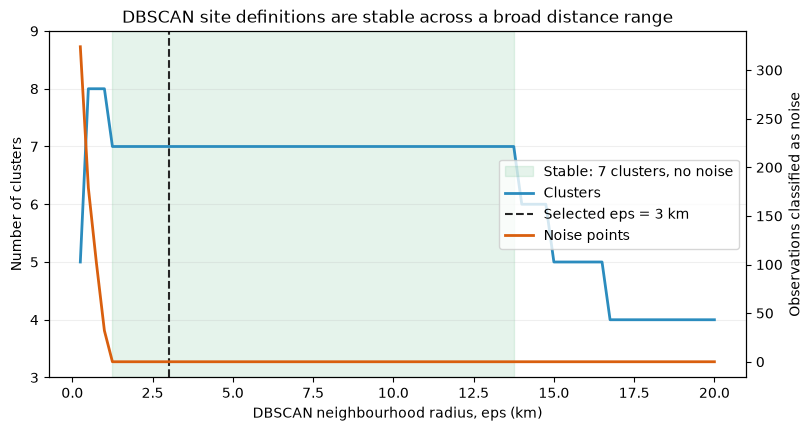

metric CRS                      EPSG:32648
selected eps (km)                      3.0
stable eps minimum (km)               1.25
stable eps maximum (km)              13.75
clusters at selected eps                 7
noise points at selected eps             0
Name: DBSCAN audit, dtype: object

In [3]:
# Check whether the seven-site solution is stable across plausible neighbourhood radii.
eps_grid_km = np.arange(0.25, 20.25, 0.25)
sensitivity_rows = []
for eps_km in eps_grid_km:
    candidate_labels = DBSCAN(
        eps=eps_km * 1_000,
        min_samples=DBSCAN_MIN_SAMPLES,
    ).fit_predict(projected_coordinates_m)
    sensitivity_rows.append(
        {
            "eps_km": eps_km,
            "clusters": len(set(candidate_labels) - {-1}),
            "noise_points": int((candidate_labels == -1).sum()),
        }
    )

dbscan_sensitivity = pd.DataFrame(sensitivity_rows)
stable_solution = dbscan_sensitivity.query("clusters == 7 and noise_points == 0")
stable_eps_min = stable_solution["eps_km"].min()
stable_eps_max = stable_solution["eps_km"].max()

assert stable_eps_min <= DBSCAN_EPS_KM <= stable_eps_max

fig, cluster_axis = plt.subplots(figsize=(9, 4.5))
noise_axis = cluster_axis.twinx()
cluster_axis.axvspan(
    stable_eps_min,
    stable_eps_max,
    color="#2ca25f",
    alpha=0.12,
    label="Stable: 7 clusters, no noise",
)
cluster_axis.plot(
    dbscan_sensitivity["eps_km"],
    dbscan_sensitivity["clusters"],
    color="#2b8cbe",
    linewidth=2,
    label="Clusters",
)
noise_axis.plot(
    dbscan_sensitivity["eps_km"],
    dbscan_sensitivity["noise_points"],
    color="#d95f0e",
    linewidth=2,
    label="Noise points",
)
cluster_axis.axvline(
    DBSCAN_EPS_KM,
    color="#252525",
    linestyle="--",
    linewidth=1.5,
    label=f"Selected eps = {DBSCAN_EPS_KM:g} km",
)
cluster_axis.set(
    title="DBSCAN site definitions are stable across a broad distance range",
    xlabel="DBSCAN neighbourhood radius, eps (km)",
    ylabel="Number of clusters",
    yticks=range(3, 10),
)
noise_axis.set_ylabel("Observations classified as noise")
cluster_axis.grid(axis="y", alpha=0.2)
handles_1, labels_1 = cluster_axis.get_legend_handles_labels()
handles_2, labels_2 = noise_axis.get_legend_handles_labels()
cluster_axis.legend(handles_1 + handles_2, labels_1 + labels_2, loc="center right")
plt.show()

pd.Series(
    {
        "metric CRS": sampling_crs.ogc_string(),
        "selected eps (km)": DBSCAN_EPS_KM,
        "stable eps minimum (km)": stable_eps_min,
        "stable eps maximum (km)": stable_eps_max,
        "clusters at selected eps": crop_labels["site_id"].nunique(),
        "noise points at selected eps": int((crop_labels["site_id"] == -1).sum()),
    },
    name="DBSCAN audit",
)


**Remark**: DBSCAN was applied after projecting the latitude and longitude coordinates into UTM zone 48N, ensuring that distances are measured in metres rather than geographic degrees. The seven-site solution remains unchanged, with no noise points, for neighbourhood radii between 1.25 km and 13.75 km. Therefore, the selected radius of 3 km lies within a broad stable interval, indicating that the identified sites reflect genuine spatial clusters rather than an arbitrary DBSCAN parameter choice. Class labels were not used during clustering.


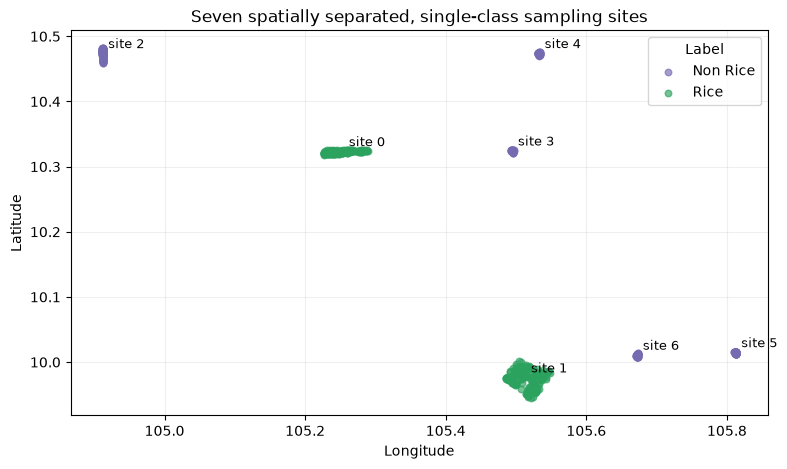

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
palette = {"Rice": "#2ca25f", "Non Rice": "#756bb1"}
for label, subset in crop_labels.groupby("Class of Land"):
    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        s=22,
        alpha=0.65,
        label=label,
        color=palette[label],
    )
for _, site in site_summary.iterrows():
    ax.annotate(
        f"site {int(site.site_id)}",
        (site.longitude, site.latitude),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
    )
ax.set(title="Seven spatially separated, single-class sampling sites", xlabel="Longitude", ylabel="Latitude")
ax.legend(title="Label")
ax.grid(alpha=0.2)
plt.show()

### Interactive sampling-site map

Use the layer control to show or hide rice points, non-rice points, and site footprints. Hover over a point for its observation details; click a site label to inspect its class and sample count. The fullscreen, minimap, coordinate, and distance-measurement controls make the spatial structure easier to explore than in the static chart.


Image size: (2297, 1507)
Downloaded shape: (1507, 2297, 3)


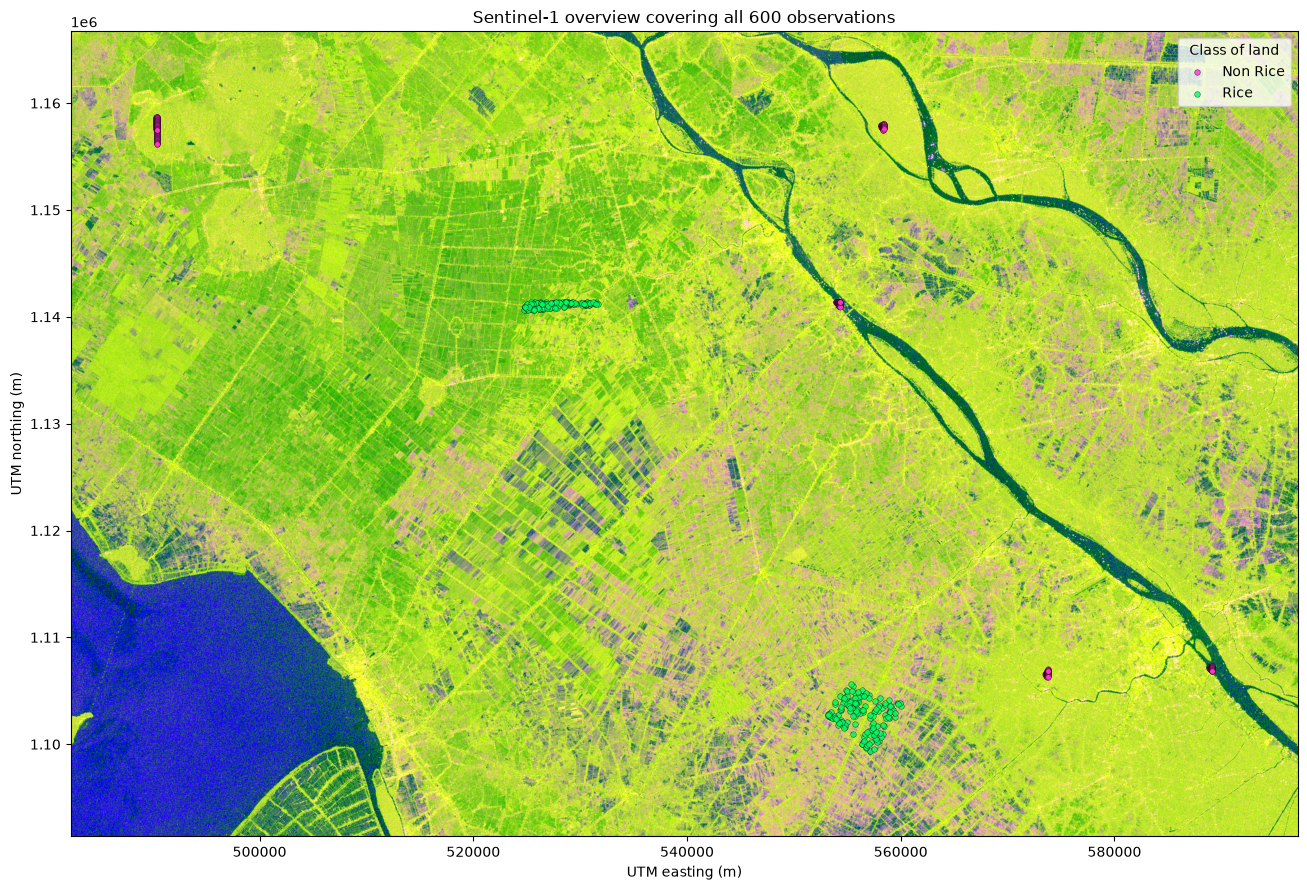

In [81]:
# Add a margin around the complete sampling region.
margin_m =  8000
min_x = crop_labels["easting_m"].min() - margin_m
max_x = crop_labels["easting_m"].max() + margin_m
min_y = crop_labels["northing_m"].min() - margin_m
max_y = crop_labels["northing_m"].max() + margin_m

overview_bbox = BBox(
    (min_x, min_y, max_x, max_y),
    crs=sampling_crs,
)

resolution_m = 50
overview_size = (
    int(np.ceil((max_x - min_x) / resolution_m)),
    int(np.ceil((max_y - min_y) / resolution_m)),
)

print("Image size:", overview_size)

OVERVIEW_EVALSCRIPT = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: ["VH", "VV", "dataMask"],
      units: ["LINEAR_POWER", "LINEAR_POWER", "DN"]
    }],
    output: {
      bands: 3,
      sampleType: "FLOAT32"
    }
  };
}

function evaluatePixel(sample) {
  return [sample.VH, sample.VV, sample.dataMask];
}
"""

config = SHConfig("cdse")

# Reuse the collection if the notebook has already defined it.
if hasattr(DataCollection, "s1iw"):
    overview_collection = DataCollection.s1iw
else:
    overview_collection = DataCollection.SENTINEL1_IW.define_from(
        "s1iw",
        service_url=config.sh_base_url,
    )

overview_request = SentinelHubRequest(
    evalscript=OVERVIEW_EVALSCRIPT,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=overview_collection,
            time_interval=("2020-07-01", "2020-07-16"),
            other_args={
                "dataFilter": {
                    "orbitDirection": "ASCENDING",
                    "mosaickingOrder": "mostRecent",
                },
                "processing": {
                    "backCoeff": "GAMMA0_TERRAIN",
                    "orthorectify": True,
                    "demInstance": "COPERNICUS",
                },
            },
        )
    ],
    responses=[
        SentinelHubRequest.output_response("default", MimeType.TIFF)
    ],
    bbox=overview_bbox,
    size=overview_size,
    config=config,
)

overview_image = np.asarray(overview_request.get_data()[0], dtype=float)
print("Downloaded shape:", overview_image.shape)

### Create a Sentinel-1 false-colour image

vh = overview_image[..., 0]
vv = overview_image[..., 1]
valid = overview_image[..., 2] > 0

eps = 1e-8
vh_db = 10 * np.log10(np.clip(vh, eps, None))
vv_db = 10 * np.log10(np.clip(vv, eps, None))
difference_db = vv_db - vh_db


def percentile_stretch(values, mask, low=2, high=98):
    valid_values = values[mask & np.isfinite(values)]
    lower, upper = np.percentile(valid_values, [low, high])

    return np.clip(
        (values - lower) / (upper - lower),
        0,
        1,
    )


rgb = np.dstack([
    percentile_stretch(vv_db, valid),        # Red: VV
    percentile_stretch(vh_db, valid),        # Green: VH
    percentile_stretch(difference_db, valid) # Blue: VV−VH
])

rgb[~valid] = 0


fig, ax = plt.subplots(figsize=(14, 9))

ax.imshow(
    rgb,
    extent=(min_x, max_x, min_y, max_y),
    origin="upper",
)

palette = {
    "Rice": "#00ff66",
    "Non Rice": "#ff33cc",
}

for label, subset in crop_labels.groupby("Class of Land"):
    ax.scatter(
        subset["easting_m"],
        subset["northing_m"],
        s=16,
        color=palette[label],
        edgecolor="black",
        linewidth=0.3,
        alpha=0.8,
        label=label,
    )

ax.set(
    title="Sentinel-1 overview covering all 600 observations",
    xlabel="UTM easting (m)",
    ylabel="UTM northing (m)",
)

ax.legend(title="Class of land")
plt.tight_layout()
plt.show()

In [60]:
from folium import plugins


map_center = [crop_labels["latitude"].mean(), crop_labels["longitude"].mean()]
sampling_map = folium.Map(
    location=map_center,
    zoom_start=9,
    tiles=None,
    control_scale=True,
    prefer_canvas=True,
)

# Two switchable, high-contrast basemaps.
folium.TileLayer("CartoDB positron", name="Light basemap", control=True).add_to(sampling_map)
folium.TileLayer("OpenStreetMap", name="Street map", control=True).add_to(sampling_map)

point_layers = {
    label: folium.FeatureGroup(name=f"{label} observations", show=True)
    for label in ("Rice", "Non Rice")
}
site_layer = folium.FeatureGroup(name="Site footprints and labels", show=True)

# Observation-level markers with rich hover information.
for observation_id, observation in crop_labels.iterrows():
    label = observation["Class of Land"]
    tooltip = folium.Tooltip(
        f"<b>Observation {observation_id}</b><br>"
        f"Class: {label}<br>"
        f"Site: {int(observation.site_id)}<br>"
        f"Lat: {observation.latitude:.6f}<br>"
        f"Lon: {observation.longitude:.6f}",
        sticky=False,
    )
    folium.CircleMarker(
        location=[observation.latitude, observation.longitude],
        radius=3.5,
        color="#ffffff",
        weight=0.8,
        fill=True,
        fill_color=palette[label],
        fill_opacity=0.82,
        tooltip=tooltip,
    ).add_to(point_layers[label])

# Draw each site's metric-CRS footprint and label its centroid.
for _, site in site_summary.iterrows():
    site_id = int(site.site_id)
    label = site["Class of Land"]
    site_points = crop_labels[crop_labels["site_id"] == site_id]
    radial_distance_m = np.hypot(
        site_points["easting_m"] - site.easting_m,
        site_points["northing_m"] - site.northing_m,
    )
    radius_m = max(300.0, radial_distance_m.max() + 150)

    folium.Circle(
        location=[site.latitude, site.longitude],
        radius=radius_m,
        color=palette[label],
        weight=2,
        dash_array="7 5",
        fill=True,
        fill_color=palette[label],
        fill_opacity=0.08,
        tooltip=f"Site {site_id}: {label} ({int(site.observations)} observations)",
    ).add_to(site_layer)

    folium.Marker(
        location=[site.latitude, site.longitude],
        icon=folium.DivIcon(
            icon_size=(90, 28),
            icon_anchor=(45, 14),
            html=(
                f'<div style="background:white;border:2px solid {palette[label]};'
                'border-radius:12px;padding:3px 7px;text-align:center;'
                'font-size:11px;font-weight:700;white-space:nowrap;'
                'box-shadow:0 1px 4px rgba(0,0,0,.25)">'
                f'Site {site_id}</div>'
            ),
        ),
        popup=folium.Popup(
            f"<b>Site {site_id}</b><br>Class: {label}<br>"
            f"Observations: {int(site.observations)}<br>"
            f"Centroid: {site.latitude:.5f}, {site.longitude:.5f}",
            max_width=250,
        ),
    ).add_to(site_layer)

for layer in point_layers.values():
    layer.add_to(sampling_map)
site_layer.add_to(sampling_map)

# Map title and fixed legend.
title_html = """
<div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);z-index:9999;
background:rgba(255,255,255,.94);padding:8px 16px;border-radius:8px;
box-shadow:0 1px 5px rgba(0,0,0,.25);font-size:16px;font-weight:700;">
Rice-crop observations and spatial validation sites
</div>
"""
legend_html = f"""
<div style="position:fixed;bottom:28px;left:28px;z-index:9999;background:rgba(255,255,255,.94);
padding:10px 13px;border-radius:8px;box-shadow:0 1px 5px rgba(0,0,0,.25);font-size:12px;">
<div style="font-weight:700;margin-bottom:6px;">Class of land</div>
<div><span style="display:inline-block;width:11px;height:11px;border-radius:50%;background:{palette['Rice']};margin-right:7px;"></span>Rice</div>
<div><span style="display:inline-block;width:11px;height:11px;border-radius:50%;background:{palette['Non Rice']};margin-right:7px;"></span>Non Rice</div>
<div style="margin-top:6px;color:#555;">Dashed circles show site extent</div>
</div>
"""
sampling_map.get_root().html.add_child(folium.Element(title_html + legend_html))

plugins.Fullscreen(position="topright", title="Fullscreen", title_cancel="Exit fullscreen").add_to(sampling_map)
plugins.MiniMap(toggle_display=True, minimized=True, position="bottomright").add_to(sampling_map)
plugins.MousePosition(
    position="bottomright",
    separator=" | ",
    prefix="Coordinates:",
    num_digits=5,
).add_to(sampling_map)
plugins.MeasureControl(position="topleft", primary_length_unit="kilometers").add_to(sampling_map)
folium.LayerControl(collapsed=False, position="topright").add_to(sampling_map)

sampling_map.fit_bounds(
    [
        [crop_labels["latitude"].min(), crop_labels["longitude"].min()],
        [crop_labels["latitude"].max(), crop_labels["longitude"].max()],
    ],
    padding=(25, 25),
)
sampling_map

In [73]:
map_example_observation

CropObservation(latitude=10.323727047081501, longitude=105.2516346045924, land_class='Rice', vh=array([[0.02597782, 0.02597782, 0.04451399, 0.05280247, 0.06314147,
        0.0631909 , 0.04614105, 0.03121324, 0.06562941],
       [0.04527651, 0.02292088, 0.03743306, 0.03124806, 0.05290626,
        0.06733079, 0.04564087, 0.03265624, 0.08693296],
       [0.03196554, 0.01335901, 0.02384821, 0.04122181, 0.0428933 ,
        0.06069698, 0.07733919, 0.08136026, 0.08073068],
       [0.01954188, 0.01796691, 0.04046922, 0.05030481, 0.03801677,
        0.05145404, 0.06723318, 0.08140443, 0.08073068],
       [0.01107826, 0.01643025, 0.04046875, 0.05030481, 0.05169869,
        0.06050724, 0.0472853 , 0.05054126, 0.06537207],
       [0.01026504, 0.01072327, 0.01917122, 0.01917122, 0.03881085,
        0.06241991, 0.05849062, 0.04391603, 0.06790741],
       [0.00984146, 0.01750763, 0.02146865, 0.02511474, 0.03316348,
        0.04655684, 0.0604658 , 0.04236872, 0.05745512],
       [0.0220148 , 0.0231887

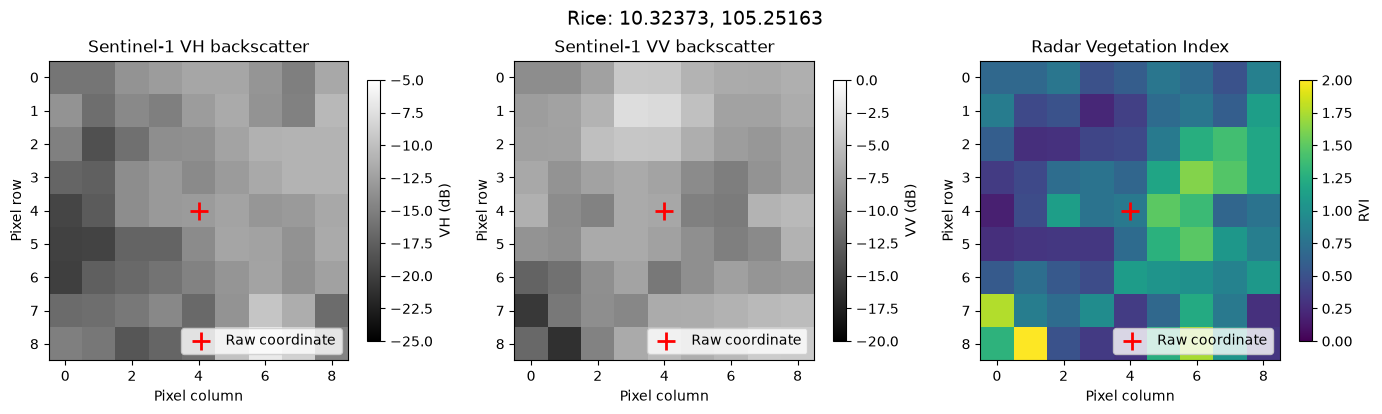

In [74]:
observation = map_example_observation

# Convert linear radar power to decibels for easier visualization.
eps = 1e-8
vh_db = 10 * np.log10(np.clip(observation.vh, eps, None))
vv_db = 10 * np.log10(np.clip(observation.vv, eps, None))

with np.errstate(divide="ignore", invalid="ignore"):
    rvi = 4 * observation.vh / (observation.vh + observation.vv)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

images = [
    axes[0].imshow(vh_db, cmap="gray", vmin=-25, vmax=-5),
    axes[1].imshow(vv_db, cmap="gray", vmin=-20, vmax=0),
    axes[2].imshow(rvi, cmap="viridis", vmin=0, vmax=2),
]

titles = [
    "Sentinel-1 VH backscatter",
    "Sentinel-1 VV backscatter",
    "Radar Vegetation Index",
]

labels = ["VH (dB)", "VV (dB)", "RVI"]

for ax, image, title, label in zip(axes, images, titles, labels):
    ax.scatter(
        4,
        4,
        marker="+",
        s=160,
        linewidth=2,
        color="red",
        label="Raw coordinate",
    )
    ax.set_title(title)
    ax.set_xlabel("Pixel column")
    ax.set_ylabel("Pixel row")
    ax.legend(loc="lower right")
    fig.colorbar(image, ax=ax, label=label, shrink=0.82)

fig.suptitle(
    f"{observation.land_class}: "
    f"{observation.latitude:.5f}, {observation.longitude:.5f}",
    fontsize=14,
)
plt.tight_layout()
plt.show()

There are only **seven independent spatial sites**: two rice and five non-rice. Because every site is single-class, a random row split puts near-neighbours from every site into both train and test sets. It measures interpolation within known sites, not transfer to a new site.

### 2. Build or load the Sentinel-1 feature cache

For each 15-day interval in 2020, the code requests one gamma0 terrain-corrected ascending-orbit raster per site. Every observation is summarized from its centred 9×9 (90 m × 90 m) window. This produces VH, VV, VH/VV and dual-pol RVI features while reducing the API workload from thousands of point-date requests to 175 site-period requests.

The cache is reused on later runs. The design follows the official [Statistical API guidance on temporal intervals](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Statistical.html), [Sentinel-1 GRD processing options](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/S1GRD.html), and the [Process API request contract](https://sentinelhub-py.readthedocs.io/en/latest/reference/sentinelhub.api.process.html).

In [21]:
MODEL_EVALSCRIPT = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: ["VH", "VV", "dataMask"],
      units: ["LINEAR_POWER", "LINEAR_POWER", "DN"]
    }],
    output: {bands: 3, sampleType: "FLOAT32"}
  };
}
function evaluatePixel(sample) {
  return [sample.VH, sample.VV, sample.dataMask];
}
"""


def _site_request_metadata(label_data, resolution=10.0, window_size=9):
    """Create aligned UTM request bounds for each discovered site."""
    sites = []
    for site_id, site in label_data.groupby("site_id", sort=True):
        center_lat, center_lon = site[["latitude", "longitude"]].mean()
        crs = CRS.get_utm_from_wgs84(lng=center_lon, lat=center_lat)
        transformer = Transformer.from_crs(CRS.WGS84.pyproj_crs(), crs.pyproj_crs(), always_xy=True)
        eastings, northings = transformer.transform(site["longitude"], site["latitude"])
        padding = window_size * resolution / 2
        min_x = math.floor((eastings.min() - padding) / resolution) * resolution
        max_x = math.ceil((eastings.max() + padding) / resolution) * resolution
        min_y = math.floor((northings.min() - padding) / resolution) * resolution
        max_y = math.ceil((northings.max() + padding) / resolution) * resolution
        sites.append(
            {
                "site_id": int(site_id),
                "indices": site.index.to_numpy(),
                "eastings": np.asarray(eastings),
                "northings": np.asarray(northings),
                "bbox": BBox((min_x, min_y, max_x, max_y), crs=crs),
                "size": (int((max_x - min_x) / resolution), int((max_y - min_y) / resolution)),
                "bounds": (min_x, min_y, max_x, max_y),
            }
        )
    return sites


def _window_statistics(window, observation_id, site_id, date):
    valid = window[..., 2] > 0
    vh = np.where(valid, window[..., 0], np.nan)
    vv = np.where(valid, window[..., 1], np.nan)
    with np.errstate(divide="ignore", invalid="ignore"):
        rvi = np.where(vh + vv > 0, 4 * vh / (vh + vv), np.nan)
        ratio = np.where(vv > 0, vh / vv, np.nan)

    rows = []
    for name, values in (("vh", vh), ("vv", vv), ("rvi", rvi), ("ratio", ratio)):
        finite = values[np.isfinite(values)]
        rows.append(
            {
                "observation_id": observation_id,
                "site_id": site_id,
                "date": date,
                "feature": name,
                "mean": np.mean(finite) if finite.size else np.nan,
                "stdev": np.std(finite) if finite.size else np.nan,
                "p25": np.percentile(finite, 25) if finite.size else np.nan,
                "median": np.median(finite) if finite.size else np.nan,
                "p75": np.percentile(finite, 75) if finite.size else np.nan,
                "sample_count": finite.size,
                "no_data_count": values.size - finite.size,
            }
        )
    return rows


def download_time_series_cache(label_data, path=CACHE_PATH, max_threads=2):
    """Download site rasters, extract 9×9 point windows and save a reusable cache."""
    config = SHConfig("cdse")
    collection = DataCollection.SENTINEL1_IW.define_from("s1iw", service_url=config.sh_base_url)
    starts = pd.date_range("2020-01-01", "2020-12-31", freq="15D")
    sites = _site_request_metadata(label_data)
    request_specs = []
    for site in sites:
        for start in starts:
            end = min(start + pd.Timedelta(days=15), pd.Timestamp("2021-01-01"))
            request = SentinelHubRequest(
                evalscript=MODEL_EVALSCRIPT,
                input_data=[
                    SentinelHubRequest.input_data(
                        data_collection=collection,
                        time_interval=(start.date().isoformat(), end.date().isoformat()),
                        other_args={
                            "dataFilter": {"orbitDirection": "ASCENDING"},
                            "processing": {
                                "backCoeff": "GAMMA0_TERRAIN",
                                "orthorectify": True,
                                "demInstance": "COPERNICUS",
                            },
                        },
                    )
                ],
                responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
                bbox=site["bbox"],
                size=site["size"],
                config=config,
            )
            request_specs.append((site, start.date().isoformat(), request.download_list[0]))

    rows = []
    client = SentinelHubDownloadClient(config=config)
    for batch_start in tqdm(range(0, len(request_specs), 6), desc="Site-period batches"):
        batch = request_specs[batch_start : batch_start + 6]
        images = client.download([spec[2] for spec in batch], max_threads=max_threads)
        for (site, date, _), image in zip(batch, images):
            image = np.asarray(image, dtype=float)
            min_x, _, _, max_y = site["bounds"]
            for observation_id, easting, northing in zip(site["indices"], site["eastings"], site["northings"]):
                column = int(np.floor((easting - min_x) / 10.0))
                row = int(np.floor((max_y - northing) / 10.0))
                window = image[row - 4 : row + 5, column - 4 : column + 5]
                if window.shape != (9, 9, 3):
                    raise RuntimeError(f"Unexpected window shape {window.shape} at row {observation_id}")
                rows.extend(_window_statistics(window, observation_id, site["site_id"], date))
    result = pd.DataFrame(rows)
    result.to_csv(path, index=False, compression="gzip")
    return result

In [22]:
if CACHE_PATH.exists():
    sar_long = pd.read_csv(CACHE_PATH)
else:
    sar_long = download_time_series_cache(crop_labels)

expected_columns = {
    "observation_id", "site_id", "date", "feature", "mean", "stdev",
    "p25", "median", "p75", "sample_count", "no_data_count",
}
assert expected_columns.issubset(sar_long.columns)
assert sar_long["observation_id"].nunique() == len(crop_labels)
assert sar_long["site_id"].nunique() == crop_labels["site_id"].nunique()
assert sar_long["date"].nunique() == 25
assert sar_long["feature"].nunique() == 4

cached_sites = sar_long.groupby("observation_id")["site_id"].first().sort_index()
assert np.array_equal(cached_sites.to_numpy(), crop_labels["site_id"].to_numpy())

coverage = pd.Series(
    {
        "rows": len(sar_long),
        "observations": sar_long["observation_id"].nunique(),
        "sites": sar_long["site_id"].nunique(),
        "15-day periods": sar_long["date"].nunique(),
        "valid feature rows": sar_long["median"].notna().mean(),
    },
    name="cache audit",
)
coverage

rows                  60000.00
observations            600.00
sites                     7.00
15-day periods           25.00
valid feature rows        0.96
Name: cache audit, dtype: float64

In [27]:
sar_long

,observation_id,site_id,date,feature,mean,stdev,p25,median,p75,sample_count,no_data_count
0,0,0,2020-01-01,vh,0.025129,0.014082,0.015148,0.021890,0.035740,81,0
1,0,0,2020-01-01,vv,0.147630,0.083132,0.087558,0.131989,0.199617,81,0
2,0,0,2020-01-01,rvi,0.708139,0.433700,0.405689,0.644853,0.987633,81,0
3,0,0,2020-01-01,ratio,0.239541,0.188307,0.112870,0.192198,0.327859,81,0
4,1,0,2020-01-01,vh,0.011603,0.005707,0.007892,0.010853,0.013622,81,0
...,...,...,...,...,...,...,...,...,...,...,...
59995,598,6,2020-12-26,ratio,NaN,NaN,NaN,NaN,NaN,0,81
59996,599,6,2020-12-26,vh,NaN,NaN,NaN,NaN,NaN,0,81
59997,599,6,2020-12-26,vv,NaN,NaN,NaN,NaN,NaN,0,81
59998,599,6,2020-12-26,rvi,NaN,NaN,NaN,NaN,NaN,0,81


In [30]:
sar_long.dtypes

observation_id      int64
site_id             int64
date                  str
feature               str
mean              float64
stdev             float64
p25               float64
median            float64
p75               float64
sample_count        int64
no_data_count       int64
dtype: object

In [35]:
crop_labels

,Latitude and Longitude,Class of Land,latitude,longitude,target,site_id
0,"(10.323727047081501, 105.2516346045924)",Rice,10.323727,105.251635,1,0
1,"(10.322364360592521, 105.27843410554115)",Rice,10.322364,105.278434,1,0
2,"(10.321455902933202, 105.25254306225168)",Rice,10.321456,105.252543,1,0
3,"(10.324181275911162, 105.25118037576274)",Rice,10.324181,105.251180,1,0
4,"(10.324635504740822, 105.27389181724476)",Rice,10.324636,105.273892,1,0
...,...,...,...,...,...,...
595,"(10.013942985253381, 105.67361318732796)",Non Rice,10.013943,105.673613,0,6
596,"(10.01348875642372, 105.67361318732796)",Non Rice,10.013489,105.673613,0,6
597,"(10.013034527594062, 105.67361318732796)",Non Rice,10.013035,105.673613,0,6
598,"(10.012580298764401, 105.67361318732796)",Non Rice,10.012580,105.673613,0,6


In [32]:
jan_1 = sar_long[sar_long["date"] == "2020-01-01"]

In [34]:
jan_1

,observation_id,site_id,date,feature,mean,stdev,p25,median,p75,sample_count,no_data_count
0,0,0,2020-01-01,vh,0.025129,0.014082,0.015148,0.021890,0.035740,81,0
1,0,0,2020-01-01,vv,0.147630,0.083132,0.087558,0.131989,0.199617,81,0
2,0,0,2020-01-01,rvi,0.708139,0.433700,0.405689,0.644853,0.987633,81,0
3,0,0,2020-01-01,ratio,0.239541,0.188307,0.112870,0.192198,0.327859,81,0
4,1,0,2020-01-01,vh,0.011603,0.005707,0.007892,0.010853,0.013622,81,0
...,...,...,...,...,...,...,...,...,...,...,...
55195,598,6,2020-01-01,ratio,0.332601,0.316065,0.179243,0.246283,0.391102,81,0
55196,599,6,2020-01-01,vh,0.062178,0.029532,0.034172,0.058914,0.080992,81,0
55197,599,6,2020-01-01,vv,0.223995,0.092129,0.150066,0.215496,0.302007,81,0
55198,599,6,2020-01-01,rvi,0.944497,0.554746,0.567645,0.795799,1.175997,81,0


In [55]:
crop_labels

,Latitude and Longitude,Class of Land,latitude,longitude,target,site_id
0,"(10.323727047081501, 105.2516346045924)",Rice,10.323727,105.251635,1,0
1,"(10.322364360592521, 105.27843410554115)",Rice,10.322364,105.278434,1,0
2,"(10.321455902933202, 105.25254306225168)",Rice,10.321456,105.252543,1,0
3,"(10.324181275911162, 105.25118037576274)",Rice,10.324181,105.251180,1,0
4,"(10.324635504740822, 105.27389181724476)",Rice,10.324636,105.273892,1,0
...,...,...,...,...,...,...
595,"(10.013942985253381, 105.67361318732796)",Non Rice,10.013943,105.673613,0,6
596,"(10.01348875642372, 105.67361318732796)",Non Rice,10.013489,105.673613,0,6
597,"(10.013034527594062, 105.67361318732796)",Non Rice,10.013035,105.673613,0,6
598,"(10.012580298764401, 105.67361318732796)",Non Rice,10.012580,105.673613,0,6


### 3. Explore seasonal SAR behaviour

The curves below use medians from the 9×9 windows. They are descriptive only; all model preprocessing is fitted separately within each validation fold.

In [38]:
plot_data = sar_long.merge(
    crop_labels[["Class of Land"]],
    left_on="observation_id",
    right_index=True,
)
plot_data["date"] = pd.to_datetime(plot_data["date"])

In [41]:
plot_data

,observation_id,site_id,date,feature,mean,stdev,p25,median,p75,sample_count,no_data_count,Class of Land
0,0,0,2020-01-01,vh,0.025129,0.014082,0.015148,0.021890,0.035740,81,0,Rice
1,0,0,2020-01-01,vv,0.147630,0.083132,0.087558,0.131989,0.199617,81,0,Rice
2,0,0,2020-01-01,rvi,0.708139,0.433700,0.405689,0.644853,0.987633,81,0,Rice
3,0,0,2020-01-01,ratio,0.239541,0.188307,0.112870,0.192198,0.327859,81,0,Rice
4,1,0,2020-01-01,vh,0.011603,0.005707,0.007892,0.010853,0.013622,81,0,Rice
...,...,...,...,...,...,...,...,...,...,...,...,...
59995,598,6,2020-12-26,ratio,NaN,NaN,NaN,NaN,NaN,0,81,Non Rice
59996,599,6,2020-12-26,vh,NaN,NaN,NaN,NaN,NaN,0,81,Non Rice
59997,599,6,2020-12-26,vv,NaN,NaN,NaN,NaN,NaN,0,81,Non Rice
59998,599,6,2020-12-26,rvi,NaN,NaN,NaN,NaN,NaN,0,81,Non Rice


In [40]:
plot_data.dtypes

observation_id             int64
site_id                    int64
date              datetime64[us]
feature                      str
mean                     float64
stdev                    float64
p25                      float64
median                   float64
p75                      float64
sample_count               int64
no_data_count              int64
Class of Land                str
dtype: object

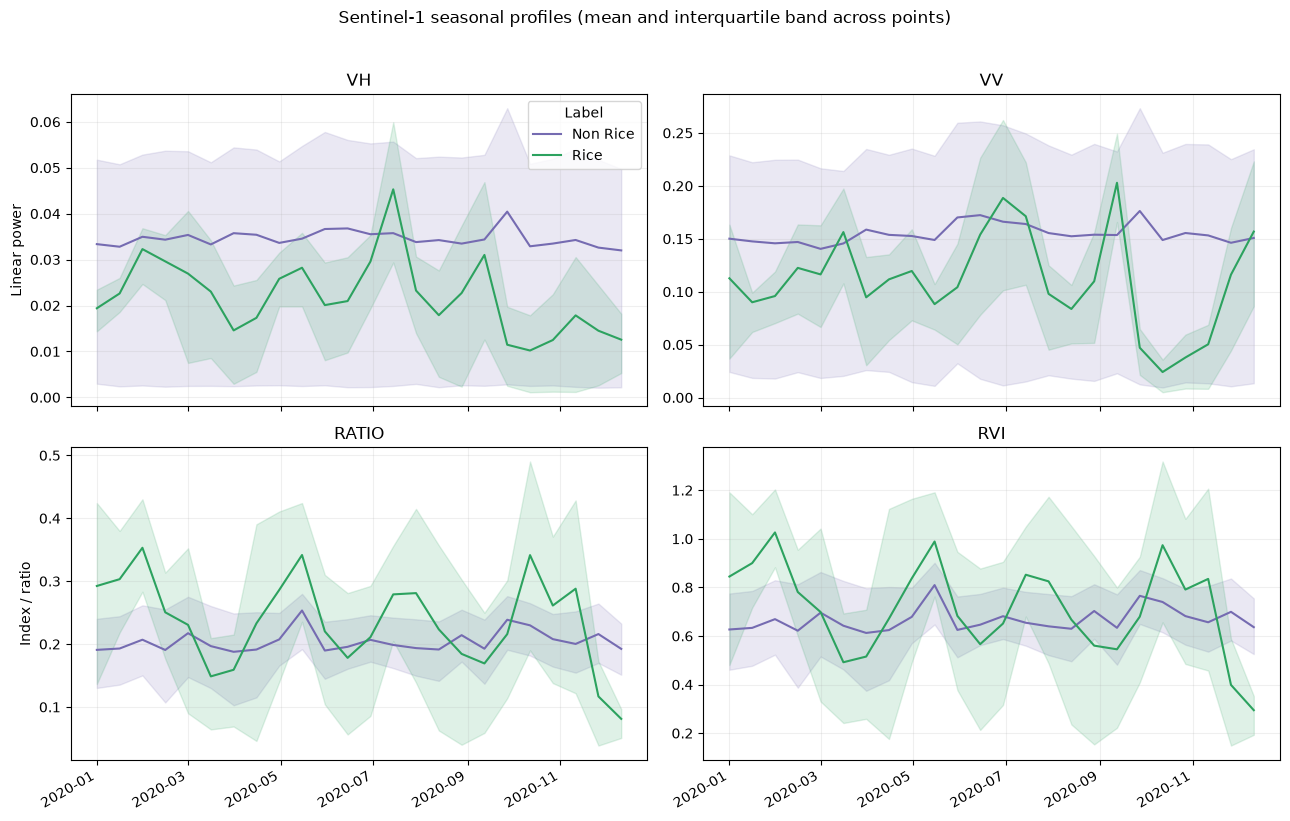

In [9]:
plot_data = sar_long.merge(
    crop_labels[["Class of Land"]],
    left_on="observation_id",
    right_index=True,
)
plot_data["date"] = pd.to_datetime(plot_data["date"])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, feature in zip(axes.flat, ["vh", "vv", "ratio", "rvi"]):
    feature_data = plot_data[plot_data["feature"] == feature]
    for label, subset in feature_data.groupby("Class of Land"):
        summary = subset.groupby("date")["median"].agg(
            mean="mean",
            lower=lambda values: values.quantile(0.25),
            upper=lambda values: values.quantile(0.75),
        )
        ax.plot(summary.index, summary["mean"], label=label, color=palette[label])
        ax.fill_between(summary.index, summary["lower"], summary["upper"], color=palette[label], alpha=0.15)
    ax.set_title(feature.upper())
    ax.grid(alpha=0.2)
axes[0, 0].set_ylabel("Linear power")
axes[1, 0].set_ylabel("Index / ratio")
axes[0, 0].legend(title="Label")
fig.suptitle("Sentinel-1 seasonal profiles (mean and interquartile band across points)", y=1.02)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### 4. Engineer phase-invariant phenology features

Absolute calendar dates performed poorly when an entire rice site was held out because planting calendars differ between regions. Instead, each annual curve is represented by distribution and change descriptors: mean, spread, quantiles, amplitude, mean absolute change, maximum rise/fall and change variability. This preserves rice phenology while making the representation less sensitive to when the season starts.

In [44]:
def temporal_descriptors(values):
    """Summarize a seasonal curve without encoding its absolute calendar phase."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {}
    differences = np.diff(values)
    return {
        "annual_mean": values.mean(),
        "annual_std": values.std(),
        "annual_min": values.min(),
        "annual_max": values.max(),
        "annual_range": np.ptp(values),
        "annual_p10": np.percentile(values, 10),
        "annual_p25": np.percentile(values, 25),
        "annual_median": np.median(values),
        "annual_p75": np.percentile(values, 75),
        "annual_p90": np.percentile(values, 90),
        "annual_iqr": np.percentile(values, 75) - np.percentile(values, 25),
        "mean_abs_change": np.abs(differences).mean() if differences.size else 0.0,
        "max_rise": differences.max() if differences.size else 0.0,
        "max_fall": -differences.min() if differences.size else 0.0,
        "change_std": differences.std() if differences.size else 0.0,
        "valid_periods": values.size,
    }


sar_long = sar_long.sort_values(["observation_id", "feature", "date"]).copy()
sar_long["iqr"] = sar_long["p75"] - sar_long["p25"]
feature_records = {}

In [45]:
sar_long

,observation_id,site_id,date,feature,mean,stdev,p25,median,p75,sample_count,no_data_count,iqr
3,0,0,2020-01-01,ratio,0.239541,0.188307,0.112870,0.192198,0.327859,81,0,0.214989
603,0,0,2020-01-16,ratio,0.225706,0.153996,0.120647,0.188912,0.287056,81,0,0.166409
1203,0,0,2020-01-31,ratio,0.563330,0.452697,0.263705,0.458201,0.668004,81,0,0.404299
1803,0,0,2020-02-15,ratio,0.563829,0.581259,0.224596,0.416625,0.701071,81,0,0.476475
2403,0,0,2020-03-01,ratio,0.560941,0.782764,0.194568,0.337712,0.540190,81,0,0.345622
...,...,...,...,...,...,...,...,...,...,...,...,...
59197,599,6,2020-10-27,vv,0.313333,0.141036,0.220729,0.272586,0.380632,81,0,0.159903
59397,599,6,2020-11-11,vv,0.280466,0.097229,0.211661,0.275925,0.341800,81,0,0.130140
59597,599,6,2020-11-26,vv,0.224246,0.089125,0.155147,0.208281,0.273376,81,0,0.118229
59797,599,6,2020-12-11,vv,0.237872,0.103710,0.166964,0.206763,0.299603,81,0,0.132640


In [46]:

for observation_id, observation in sar_long.groupby("observation_id", sort=True):
    record = {}
    for feature_name, feature_data in observation.groupby("feature", sort=True):
        for spatial_statistic in ("median", "mean", "stdev", "iqr"):
            for descriptor, value in temporal_descriptors(feature_data[spatial_statistic]).items():
                record[f"{spatial_statistic}__{feature_name}__{descriptor}"] = value
    feature_records[observation_id] = record

feature_table = pd.DataFrame.from_dict(feature_records, orient="index").reindex(crop_labels.index)
feature_table = feature_table.loc[:, feature_table.nunique(dropna=True) > 1]
X_model = feature_table.to_numpy()
y_model = crop_labels["target"].to_numpy()
site_groups = crop_labels["site_id"].to_numpy()

assert X_model.shape[0] == len(y_model) == len(site_groups)
assert not np.isnan(X_model).any()
print(f"Model matrix: {X_model.shape[0]} observations × {X_model.shape[1]} features")

Model matrix: 600 observations × 240 features


In [48]:
feature_table

,median__ratio__annual_mean,median__ratio__annual_std,median__ratio__annual_min,median__ratio__annual_max,median__ratio__annual_range,median__ratio__annual_p10,median__ratio__annual_p25,median__ratio__annual_median,median__ratio__annual_p75,median__ratio__annual_p90,...,iqr__vv__annual_p10,iqr__vv__annual_p25,iqr__vv__annual_median,iqr__vv__annual_p75,iqr__vv__annual_p90,iqr__vv__annual_iqr,iqr__vv__mean_abs_change,iqr__vv__max_rise,iqr__vv__max_fall,iqr__vv__change_std
0,0.255595,0.148815,0.028800,0.605636,0.576836,0.066433,0.152643,0.238774,0.351371,0.445728,...,0.027688,0.042686,0.055399,0.115491,0.148756,0.072805,0.049274,0.123146,0.108164,0.060401
1,0.230091,0.193021,0.010681,0.716397,0.705716,0.030659,0.053235,0.205575,0.368207,0.475355,...,0.029717,0.055538,0.079061,0.114515,0.169728,0.058978,0.048938,0.159034,0.116433,0.064178
2,0.222575,0.188893,0.013628,0.685604,0.671976,0.036607,0.063978,0.153023,0.381320,0.473569,...,0.030801,0.037789,0.106094,0.165871,0.204619,0.128081,0.077509,0.216853,0.218216,0.103212
3,0.206079,0.144755,0.020525,0.653282,0.632757,0.053943,0.083903,0.205143,0.292232,0.341424,...,0.022828,0.049592,0.085853,0.113814,0.137588,0.064222,0.050417,0.149187,0.130868,0.064967
4,0.245428,0.161120,0.027428,0.624304,0.596876,0.040441,0.115492,0.235536,0.365294,0.444871,...,0.017645,0.049054,0.081442,0.122138,0.194019,0.073084,0.079914,0.235516,0.189012,0.104525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.247748,0.064790,0.135528,0.399815,0.264287,0.179566,0.200851,0.231442,0.290371,0.325470,...,0.115705,0.127703,0.141940,0.163974,0.207976,0.036271,0.048285,0.106697,0.128193,0.060626
596,0.231913,0.052684,0.147132,0.353471,0.206340,0.163819,0.199041,0.227820,0.263124,0.305038,...,0.130686,0.135025,0.169662,0.201144,0.233171,0.066119,0.049274,0.117432,0.119797,0.059791
597,0.233286,0.046017,0.179408,0.376552,0.197144,0.182456,0.203479,0.221239,0.250727,0.294220,...,0.128929,0.151170,0.159885,0.182483,0.197517,0.031313,0.032708,0.087280,0.066717,0.039150
598,0.233860,0.031253,0.158836,0.300916,0.142080,0.197035,0.208887,0.243336,0.254252,0.262786,...,0.109293,0.127096,0.149233,0.169080,0.186005,0.041984,0.032426,0.083489,0.066481,0.040109


In [49]:
X_model

array([[0.25559467, 0.14881457, 0.02880033, ..., 0.12314562, 0.10816405,
        0.06040093],
       [0.230091  , 0.19302052, 0.01068093, ..., 0.15903401, 0.11643288,
        0.06417784],
       [0.22257473, 0.1888929 , 0.01362762, ..., 0.21685307, 0.21821613,
        0.10321234],
       ...,
       [0.23328642, 0.04601663, 0.17940831, ..., 0.08727971, 0.06671676,
        0.03914959],
       [0.23386006, 0.03125343, 0.15883562, ..., 0.08348931, 0.06648068,
        0.04010918],
       [0.24147946, 0.04756637, 0.15501513, ..., 0.10589994, 0.04429585,
        0.0369477 ]], shape=(600, 240))

### Visualize Rice versus Non-Rice in the engineered feature space

A scatter matrix containing all 240 columns would require 57,600 panels and would not be interpretable. Instead, the first chart ranks features by the absolute standardized difference between the two classes. The pair plot then displays the strongest feature from each SAR family (VH, VV, VH/VV ratio, and RVI).

This ranking uses the labels and is **descriptive visualization only**. It is not used to select the model inputs: the classifiers still receive the complete feature table, and all model preprocessing remains inside the spatial cross-validation folds.

In [52]:
rice_values

,median__ratio__annual_mean,median__ratio__annual_std,median__ratio__annual_min,median__ratio__annual_max,median__ratio__annual_range,median__ratio__annual_p10,median__ratio__annual_p25,median__ratio__annual_median,median__ratio__annual_p75,median__ratio__annual_p90,...,iqr__vv__annual_p10,iqr__vv__annual_p25,iqr__vv__annual_median,iqr__vv__annual_p75,iqr__vv__annual_p90,iqr__vv__annual_iqr,iqr__vv__mean_abs_change,iqr__vv__max_rise,iqr__vv__max_fall,iqr__vv__change_std
0,0.255595,0.148815,0.028800,0.605636,0.576836,0.066433,0.152643,0.238774,0.351371,0.445728,...,0.027688,0.042686,0.055399,0.115491,0.148756,0.072805,0.049274,0.123146,0.108164,0.060401
1,0.230091,0.193021,0.010681,0.716397,0.705716,0.030659,0.053235,0.205575,0.368207,0.475355,...,0.029717,0.055538,0.079061,0.114515,0.169728,0.058978,0.048938,0.159034,0.116433,0.064178
2,0.222575,0.188893,0.013628,0.685604,0.671976,0.036607,0.063978,0.153023,0.381320,0.473569,...,0.030801,0.037789,0.106094,0.165871,0.204619,0.128081,0.077509,0.216853,0.218216,0.103212
3,0.206079,0.144755,0.020525,0.653282,0.632757,0.053943,0.083903,0.205143,0.292232,0.341424,...,0.022828,0.049592,0.085853,0.113814,0.137588,0.064222,0.050417,0.149187,0.130868,0.064967
4,0.245428,0.161120,0.027428,0.624304,0.596876,0.040441,0.115492,0.235536,0.365294,0.444871,...,0.017645,0.049054,0.081442,0.122138,0.194019,0.073084,0.079914,0.235516,0.189012,0.104525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.235489,0.133813,0.057033,0.538173,0.481141,0.063438,0.147831,0.226762,0.307473,0.431544,...,0.045339,0.055308,0.070008,0.120459,0.151418,0.065151,0.036957,0.217238,0.132234,0.063849
296,0.288653,0.170536,0.045635,0.690292,0.644658,0.112494,0.157343,0.272226,0.391841,0.463056,...,0.048444,0.069843,0.095672,0.112880,0.160539,0.043037,0.044874,0.132454,0.119454,0.056323
297,0.228471,0.184393,0.027339,0.629448,0.602109,0.037613,0.054344,0.205430,0.328592,0.460058,...,0.010884,0.029467,0.062180,0.111883,0.189077,0.082416,0.065930,0.228438,0.197707,0.094678
298,0.279110,0.244221,0.021072,1.012326,0.991255,0.042231,0.071867,0.174675,0.448266,0.556999,...,0.005632,0.023376,0.036718,0.139399,0.172401,0.116023,0.056684,0.139305,0.156667,0.077667


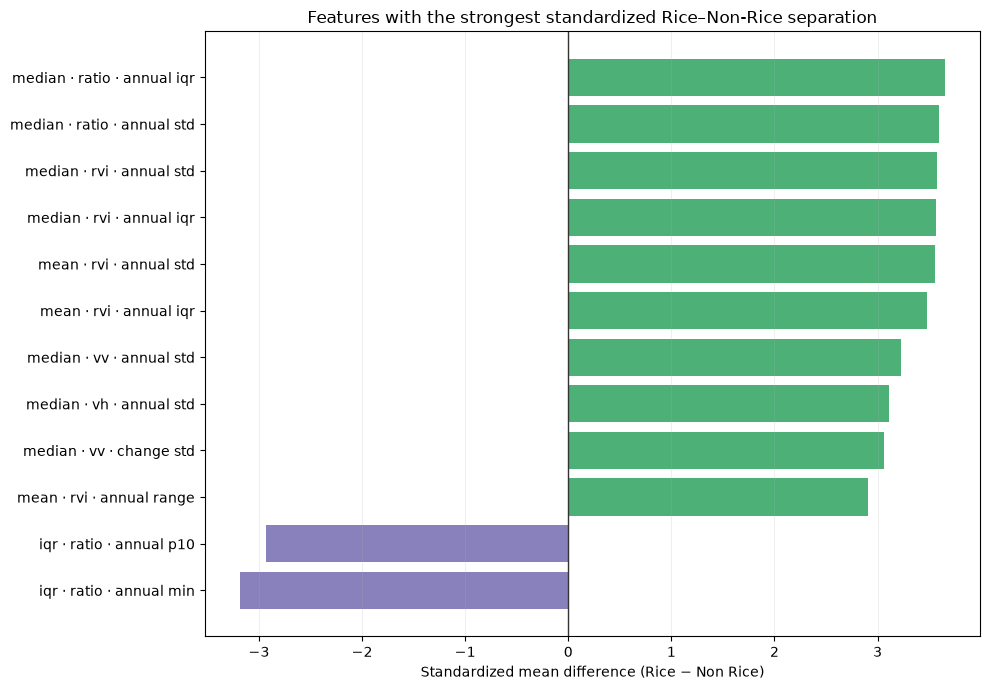

In [50]:
import textwrap


rice_values = feature_table.loc[y_model == 1]
non_rice_values = feature_table.loc[y_model == 0]
pooled_standard_deviation = np.sqrt(
    (rice_values.var(ddof=1) + non_rice_values.var(ddof=1)) / 2
)
standardized_difference = (
    (rice_values.mean() - non_rice_values.mean())
    / pooled_standard_deviation.replace(0, np.nan)
).dropna()

effect_table = (
    standardized_difference.rename("standardized_difference")
    .to_frame()
    .assign(absolute_difference=lambda frame: frame["standardized_difference"].abs())
    .sort_values("absolute_difference", ascending=False)
)

top_effects = effect_table.head(12).sort_values("standardized_difference")
wrapped_labels = [textwrap.fill(name.replace("__", " · ").replace("_", " "), 34) for name in top_effects.index]
bar_colors = [palette["Rice"] if value > 0 else palette["Non Rice"] for value in top_effects["standardized_difference"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(wrapped_labels, top_effects["standardized_difference"], color=bar_colors, alpha=0.85)
ax.axvline(0, color="#333333", linewidth=1)
ax.set(
    title="Features with the strongest standardized Rice–Non-Rice separation",
    xlabel="Standardized mean difference (Rice − Non Rice)",
    ylabel="",
)
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()

,plot_label,feature_table_column,standardized_difference
0,F1,median__vh__annual_std,+3.11
1,F2,median__vv__annual_std,+3.23
2,F3,median__ratio__annual_iqr,+3.65
3,F4,median__rvi__annual_std,+3.57


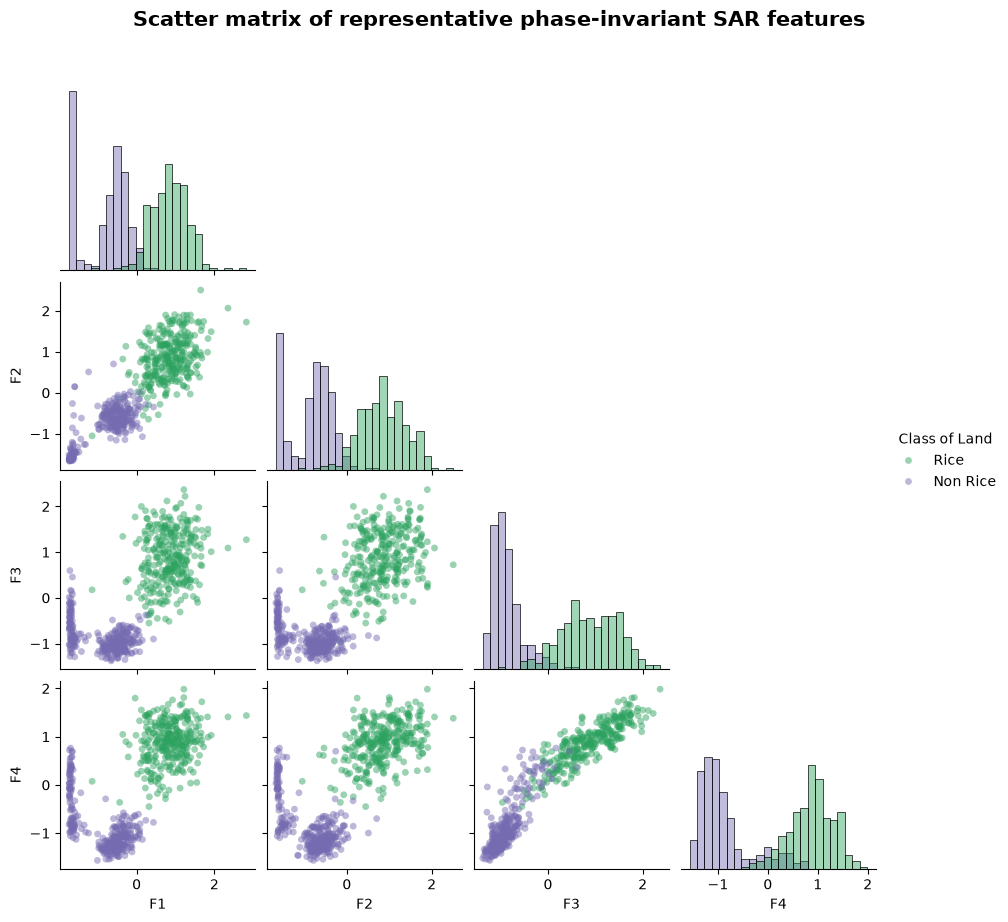

In [51]:
from IPython.display import display

# Select one strong feature from each physical SAR family to avoid a redundant matrix.
family_order = ["vh", "vv", "ratio", "rvi"]
selected_scatter_features = []
for family in family_order:
    family_candidates = [
        column
        for column in effect_table.index
        if column.split("__")[1] == family
    ]
    selected_scatter_features.append(family_candidates[0])

short_names = {feature: f"F{index}" for index, feature in enumerate(selected_scatter_features, start=1)}
feature_key = pd.DataFrame(
    {
        "plot_label": list(short_names.values()),
        "feature_table_column": selected_scatter_features,
        "standardized_difference": standardized_difference[selected_scatter_features].to_numpy(),
    }
)
display(feature_key.style.format({"standardized_difference": "{:+.2f}"}))

# Standardization is used only to put differently scaled features on comparable axes.
scatter_values = pd.DataFrame(
    StandardScaler().fit_transform(feature_table[selected_scatter_features]),
    columns=[short_names[feature] for feature in selected_scatter_features],
    index=feature_table.index,
)
scatter_values["Class of Land"] = crop_labels["Class of Land"].to_numpy()

pair_grid = sns.pairplot(
    scatter_values,
    vars=list(short_names.values()),
    hue="Class of Land",
    hue_order=["Rice", "Non Rice"],
    palette=palette,
    corner=True,
    diag_kind="hist",
    height=2.25,
    plot_kws={"s": 24, "alpha": 0.48, "edgecolor": "none"},
    diag_kws={"alpha": 0.45, "bins": 24},
)
pair_grid.fig.suptitle(
    "Scatter matrix of representative phase-invariant SAR features",
    y=1.02,
    fontsize=15,
    fontweight="bold",
)
pair_grid.fig.subplots_adjust(top=0.94)
plt.show()

How to read the matrix:

- The diagonal histograms show each feature's class distribution. Less overlap means stronger one-feature separation.
- The off-diagonal panels show pairwise relationships. Distinct green and purple clouds indicate that a combination of features can separate the classes even when either feature overlaps individually.
- Tight diagonal relationships indicate correlated or partly redundant descriptors. This is expected for RVI and VH/VV because RVI is a nonlinear transformation of the polarization ratio.
- The axes are standardized z-scores for visualization; the displayed values are not the original physical units.

### 5. Leave-one-site-out model comparison

`LeaveOneGroupOut` ensures that no point from the validation site appears in training. Imputation and scaling are inside each pipeline, so they are also learned from training sites only. This follows scikit-learn's [grouped cross-validation guidance](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data).

In [62]:
site_groups

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,

In [63]:
candidate_models = {
    "Constant non-rice": DummyClassifier(strategy="constant", constant=0),
    "Logistic regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(C=0.1, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
    ),
    "Extra Trees": make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            max_features=0.7,
            class_weight="balanced",
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
    ),
    "RBF SVM": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        SVC(C=1.0, kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    ),
}


def leave_one_site_out_predictions(estimator, X, y, groups):
    predictions = np.empty(len(y), dtype=int)
    probabilities = np.empty(len(y), dtype=float)
    splitter = LeaveOneGroupOut()
    for train_indices, test_indices in splitter.split(X, y, groups):
        fold_model = clone(estimator)
        fold_model.fit(X[train_indices], y[train_indices])
        predictions[test_indices] = fold_model.predict(X[test_indices])
        probabilities[test_indices] = fold_model.predict_proba(X[test_indices])[:, 1]
    return predictions, probabilities


model_predictions = {}
comparison_rows = []
for model_name, estimator in candidate_models.items():
    predictions, probabilities = leave_one_site_out_predictions(
        estimator, X_model, y_model, site_groups
    )
    model_predictions[model_name] = (predictions, probabilities)
    comparison_rows.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_model, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_model, predictions),
            "macro_f1": f1_score(y_model, predictions, average="macro"),
            "rice_f1": f1_score(y_model, predictions, pos_label=1),
            "roc_auc": roc_auc_score(y_model, probabilities),
            "average_precision": average_precision_score(y_model, probabilities),
        }
    )

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["macro_f1", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)
model_comparison.style.format({column: "{:.3f}" for column in model_comparison.columns if column != "model"})

,model,accuracy,balanced_accuracy,macro_f1,rice_f1,roc_auc,average_precision
0,RBF SVM,0.988,0.988,0.988,0.988,0.989,0.993
1,Logistic regression,0.950,0.950,0.950,0.952,0.992,0.993
2,Extra Trees,0.925,0.925,0.925,0.930,0.997,0.997
3,Constant non-rice,0.500,0.500,0.333,0.000,0.500,0.500


In [64]:
selected_model_name = model_comparison.iloc[0]["model"]
selected_predictions, selected_probabilities = model_predictions[selected_model_name]

site_diagnostics = []
for site_id in np.unique(site_groups):
    mask = site_groups == site_id
    site_diagnostics.append(
        {
            "site_id": site_id,
            "class": crop_labels.loc[mask, "Class of Land"].iloc[0],
            "observations": mask.sum(),
            "accuracy": accuracy_score(y_model[mask], selected_predictions[mask]),
            "mean_rice_probability": selected_probabilities[mask].mean(),
            "min_rice_probability": selected_probabilities[mask].min(),
            "max_rice_probability": selected_probabilities[mask].max(),
        }
    )

site_diagnostics = pd.DataFrame(site_diagnostics)
print(f"Selected model: {selected_model_name}")
site_diagnostics.style.format(
    {
        "accuracy": "{:.3f}",
        "mean_rice_probability": "{:.3f}",
        "min_rice_probability": "{:.3f}",
        "max_rice_probability": "{:.3f}",
    }
)

Selected model: RBF SVM


,site_id,class,observations,accuracy,mean_rice_probability,min_rice_probability,max_rice_probability
0,0,Rice,150,1.000,0.997,0.947,1.000
1,1,Rice,150,0.953,0.923,0.016,1.000
2,2,Non Rice,100,1.000,0.061,0.003,0.371
3,3,Non Rice,50,1.000,0.210,0.139,0.409
4,4,Non Rice,50,1.000,0.001,0.000,0.002
5,5,Non Rice,50,1.000,0.127,0.062,0.148
6,6,Non Rice,50,1.000,0.003,0.000,0.056


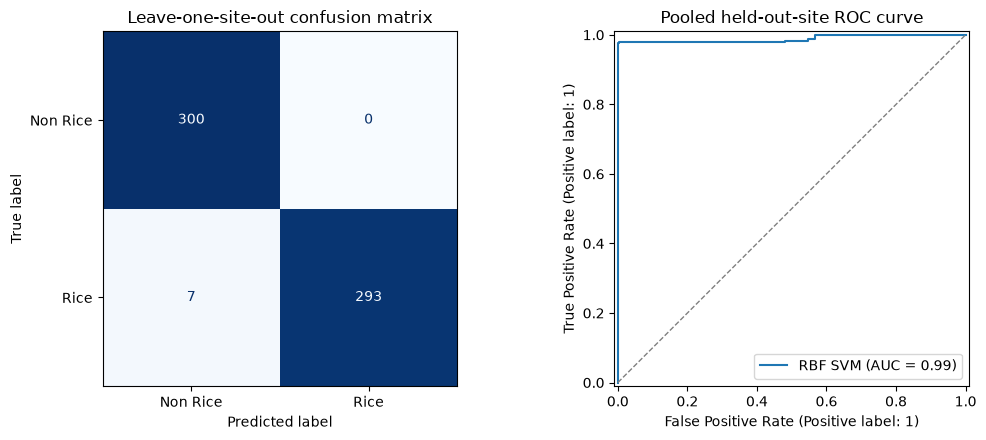

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_model,
    selected_predictions,
    display_labels=["Non Rice", "Rice"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Leave-one-site-out confusion matrix")
RocCurveDisplay.from_predictions(y_model, selected_probabilities, name=selected_model_name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
axes[1].set_title("Pooled held-out-site ROC curve")
fig.tight_layout()
plt.show()

### 6. Compare with a random row split and fit the delivery model

The comparison below uses the same feature pipeline and model. The row split is not the primary estimate because it contains observations from every site on both sides of the split.

In [66]:
selected_model_name

'RBF SVM'

In [67]:
train_indices, test_indices = train_test_split(
    np.arange(len(y_model)),
    test_size=0.30,
    stratify=y_model,
    random_state=RANDOM_STATE,
)

In [70]:
candidate_models[selected_model_name]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive est

In [71]:

random_split_model = clone(candidate_models[selected_model_name])
random_split_model.fit(X_model[train_indices], y_model[train_indices])
random_predictions = random_split_model.predict(X_model[test_indices])
random_probabilities = random_split_model.predict_proba(X_model[test_indices])[:, 1]

strict_metrics = model_comparison.set_index("model").loc[selected_model_name]
validation_comparison = pd.DataFrame(
    [
        {
            "validation": "Random 70/30 row split (optimistic)",
            "accuracy": accuracy_score(y_model[test_indices], random_predictions),
            "macro_f1": f1_score(y_model[test_indices], random_predictions, average="macro"),
            "roc_auc": roc_auc_score(y_model[test_indices], random_probabilities),
        },
        {
            "validation": "Leave one spatial site out (primary)",
            "accuracy": strict_metrics["accuracy"],
            "macro_f1": strict_metrics["macro_f1"],
            "roc_auc": strict_metrics["roc_auc"],
        },
    ]
)
validation_comparison.style.format({"accuracy": "{:.3f}", "macro_f1": "{:.3f}", "roc_auc": "{:.3f}"})

,validation,accuracy,macro_f1,roc_auc
0,Random 70/30 row split (optimistic),1.000,1.000,1.000
1,Leave one spatial site out (primary),0.988,0.988,0.989


In [72]:
# Fit the final reusable pipeline on all labelled observations only after evaluation.
final_model = clone(candidate_models[selected_model_name])
final_model.fit(X_model, y_model)
model_feature_names = feature_table.columns.tolist()

print(f"Final estimator: {selected_model_name}")
print(f"Training observations: {len(y_model)} across {len(np.unique(site_groups))} sites")
print(f"Predictor features: {len(model_feature_names)} (coordinates and site ID excluded)")

Final estimator: RBF SVM
Training observations: 600 across 7 sites
Predictor features: 240 (coordinates and site ID excluded)


### Interpretation and limitations

- The selected phase-invariant RBF SVM achieves approximately **0.988 macro F1 and accuracy** under leave-one-site-out validation, compared with 0.67 accuracy for the notebook's original single-date logistic-regression row split.
- The random row split reaches 1.00, illustrating why spatial grouping matters even when the stricter result is also strong.
- All five held-out non-rice sites are classified correctly. The more difficult of the two rice sites reaches approximately 0.953 accuracy; this is the most relevant residual risk.
- The dataset still contains only two independent rice sites. The result supports transfer between these sampled regions, but it is not evidence of universal performance across Vietnam, other years, or different acquisition geometries.
- Four candidate algorithms were compared on the same seven held-out-site folds. With too few rice sites for nested spatial validation, the selected-model score can retain modest model-selection optimism.
- A production study should add labelled rice and non-rice sites, reserve entire regions and years for final testing, and assess probability calibration before choosing an operational decision threshold.